<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transformer le socle transactionnel enrichi par l’IRIS en une base territoriale exploitable par les notebooks aval.</h3>
  <div style="color: #4b5563; font-size: 14px;">L’objectif est d’ajouter des signaux lisibles et auditables sans réduire artificiellement le périmètre des transactions. partir du socle géographique produit par le notebook 04 ; ajouter les enrichissements territoriaux un par un ; documenter les taux de rapprochement et les valeurs manquantes ; produire une base transactionnelle enrichie pour la suite du pipeline.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Politique de valeurs manquantes</h3>
  <div style="color: #4b5563; font-size: 14px;">Les jointures d’enrichissement restent non destructives : les lignes non rapprochées sont conservées, les valeurs manquantes sont documentées et les choix d’imputation sont tracés dans le pipeline. jointures conservées en left join ; variables FiLoSoFi imputées par médiane hiérarchique ; absence de signal DPE matérialisée par des indicateurs dédiés ; sélection finale des variables réalisée dans les notebooks aval.</div>
</div>

In [ ]:
# Bibliothèques standard
from pathlib import Path
from datetime import datetime
import json
import warnings

# Bibliothèques data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Géospatial
import geopandas as gpd

# Affichage notebook
from IPython.display import display

warnings.filterwarnings("ignore")

In [ ]:
# Ce notebook enrichit les transactions DVF avec des données territoriales :
# - géographie IRIS ;
# - revenus FiLoSoFi ;
# - population INSEE ;
# - logement ;
# - équipements de proximité ;
# - indicateurs territoriaux utiles à la modélisation.

# L'objectif est de construire une base immobilière enrichie,
# exploitable pour :
# - l'analyse territoriale ;
# - la segmentation géographique ;
# - le feature engineering ;
# - les futurs modèles prédictifs.

In [ ]:
# Racine canonique du projet.
PROJECT_ROOT = Path(
    r"C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE"
)

# Répertoires standards du projet.
PATHS = {
    "processed": PROJECT_ROOT / "data" / "processed",
    "external": PROJECT_ROOT / "data" / "external",
    "reports": PROJECT_ROOT / "reports",
    "figures": PROJECT_ROOT / "outputs" / "figures",
}

# Création automatique des dossiers si nécessaire.
for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

In [ ]:
# Base micro issue du notebook précédent.
INPUT_PATH = (
    PATHS["processed"]
    / "df_biens_residentiels_iris.parquet"
)

# Sorties principales du notebook.
OUTPUTS = {
    "iris_enrichi":
        PATHS["processed"] / "df_iris_territoire_enrichi.parquet",

    "micro_enrichi":
        PATHS["processed"] / "df_biens_residentiels_territoire.parquet",

    "micro_light":
        PATHS["processed"] / "df_biens_residentiels_territoire_light.parquet",

    "merge_report":
        PATHS["reports"] / "rapport_merges_territorial.csv",

    "drop_report":
        PATHS["reports"] / "rapport_retention_lignes_territorial.csv",

    "imputation_report":
        PATHS["reports"] / "rapport_imputation_territorial.csv",

    "schema_report":
        PATHS["reports"] / "schema_variables_territoriales.csv",

    "feature_dictionary":
        PATHS["reports"] / "dictionnaire_variables_territoriales.csv",

    "manifest":
        PATHS["reports"] / "manifest_territorial.json",
}

In [ ]:
# Sources externes utilisées pour l'enrichissement territorial.
CONFIG = {

    "iris_shapefile":
        PATHS["external"]
        / "insee"
        / "iris"
        / "iris-2013-01-01.shp",

    "filosofi":
        PATHS["external"]
        / "insee"
        / "filosofi"
        / "BASE_TD_FILO_IRIS_2021_DISP.csv",

    "population":
        PATHS["external"]
        / "insee"
        / "rp_population"
        / "BASE_TD_POP_IRIS_2021.csv",

    "logement":
        PATHS["external"]
        / "insee"
        / "rp_logements"
        / "BASE_TD_LOGEMENT_IRIS_2022.csv",

    "bpe":
        PATHS["external"]
        / "insee"
        / "bpe"
        / "BPE24.parquet",

    "dpe_neuf":
        PATHS["external"]
        / "ademe"
        / "dpe"
        / "dpe02neuf.csv",

    "dpe_existant":
        PATHS["external"]
        / "ademe"
        / "dpe"
        / "dpe03existant.csv",

    "departements_geometrie":
        PATHS["external"]
        / "insee"
        / "departements"
        / "departements.shp",
}

In [ ]:
# Vérification de la présence des fichiers nécessaires.

required_files = {
    "Base DVF enrichie IRIS": INPUT_PATH,
    "Shapefile IRIS": CONFIG["iris_shapefile"],
    "FiLoSoFi": CONFIG["filosofi"],
    "Population": CONFIG["population"],
    "Logement": CONFIG["logement"],
}

missing_files = []

for label, path in required_files.items():

    if path.exists():
        print(f"OK - {label} : {path.name}")

    else:
        print(f"MANQUANT - {label} : {path}")
        missing_files.append(label)

# Contrôle bloquant si un fichier essentiel manque.
if missing_files:

    raise FileNotFoundError(
        "Fichiers manquants : "
        + ", ".join(missing_files)
    )

In [ ]:
# Vérification de la présence des fichiers nécessaires.

required_files = {
    "Base DVF enrichie IRIS": INPUT_PATH,
    "Shapefile IRIS": CONFIG["iris_shapefile"],
    "FiLoSoFi": CONFIG["filosofi"],
    "Population": CONFIG["population"],
    "Logement": CONFIG["logement"],
}

missing_files = []

for label, path in required_files.items():

    if path.exists():
        print(f"OK - {label} : {path.name}")

    else:
        print(f"MANQUANT - {label} : {path}")
        missing_files.append(label)

# Contrôle bloquant si un fichier essentiel manque.
if missing_files:

    raise FileNotFoundError(
        "Fichiers manquants : "
        + ", ".join(missing_files)
    )

In [ ]:
# Horodatage de l'exécution.
RUN_TIMESTAMP = datetime.now().isoformat(timespec="seconds")

print("PROJECT_ROOT :", PROJECT_ROOT)

print("\nEntrée principale :")
print(INPUT_PATH)

print("\nSorties principales :")
for key, value in OUTPUTS.items():
    print(f"- {key} : {value.name}")

print("\nHorodatage :", RUN_TIMESTAMP)

In [ ]:

# Fonctions de validation utilisées dans tout le pipeline.
#
# Elles permettent d'arrêter explicitement le notebook si :
# - un fichier attendu est absent ;
# - une colonne obligatoire manque dans une table.
#
# L'objectif est d'éviter les erreurs silencieuses
# et de rendre les problèmes de données immédiatement lisibles.

def require_file(path: Path, label: str) -> None:
    """Vérifie qu'un fichier existe avant de l'utiliser."""

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"{label} introuvable : {path}"
        )


def require_columns(
    df: pd.DataFrame,
    required: list[str],
    df_name: str
) -> None:
    """Vérifie qu'un DataFrame contient les colonnes obligatoires."""

    missing = [
        c for c in required
        if c not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Colonnes obligatoires absentes dans {df_name} : {missing}"
        )

In [ ]:
# Fonctions de normalisation des identifiants géographiques.
#
# Les fichiers externes peuvent contenir des codes sous différents formats :
# - 75056 ;
# - "75056" ;
# - 75.0 ;
# - " 75 " ;
# - codes DOM sur 3 caractères ;
# - Corse en 2A / 2B.
#
# Ces fonctions homogénéisent les formats avant les jointures.

def _normalize_code_like(
    values,
    width: int | None = None,
    department: bool = False
):
    """
    Normalise une valeur ou une série de codes.

    La fonction accepte :
    - une valeur seule ;
    - une Series pandas ;
    - une liste ;
    - un Index.

    Elle retourne le même type logique :
    - une valeur si l'entrée est scalaire ;
    - une Series si l'entrée est multiple.
    """

    is_scalar = not isinstance(
        values,
        (pd.Series, pd.Index, list, tuple, np.ndarray)
    )

    s = (
        pd.Series([values], dtype="string")
        if is_scalar
        else pd.Series(values, dtype="string")
    )

    s = (
        s.astype("string")
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(" ", "", regex=False)
        .str.strip()
    )

    # Conversion des chaînes vides ou pseudo-nulles en valeurs manquantes.
    s = s.mask(
        s.isin(["", "<NA>", "nan", "NaN", "None"])
    )

    # Cas des départements :
    # - métropole sur deux caractères ;
    # - DROM sur trois caractères ;
    # - Corse conservée en 2A / 2B.
    if department:
        s = s.where(
            s.str.len() >= 3,
            s.str.zfill(2)
        )

    # Cas général :
    # ajout de zéros à gauche pour atteindre la largeur attendue.
    elif width is not None:
        s = s.str.zfill(width)

    return s.iloc[0] if is_scalar else s


def normalize_code_iris(values):
    """Normalise les codes IRIS sur 9 caractères."""

    return _normalize_code_like(
        values,
        width=9
    )


def normalize_code_commune(values):
    """Normalise les codes communes INSEE sur 5 caractères."""

    return _normalize_code_like(
        values,
        width=5
    )


def normalize_code_departement(values):
    """
    Normalise les codes départements.

    Métropole :
    - 01 à 95 ;
    - 2A / 2B.

    DROM :
    - 971, 972, 973, 974, 976.
    """

    return _normalize_code_like(
        values,
        department=True
    )

In [ ]:
# Fonctions de nettoyage de formats.
#
# Elles servent à préparer les clés de jointure textuelles
# et les valeurs numériques issues de fichiers INSEE ou externes.

def normalize_text_key(series: pd.Series) -> pd.Series:
    """
    Normalise une clé textuelle.

    La fonction :
    - passe le texte en majuscules ;
    - retire les accents ;
    - supprime les caractères non alphanumériques.

    Utile pour comparer des libellés de communes ou de zones
    provenant de sources différentes.
    """

    return (
        series.astype("string")
        .str.upper()
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("ascii")
        .str.replace(r"[^A-Z0-9]", "", regex=True)
    )


def to_numeric_fr(series: pd.Series) -> pd.Series:
    """
    Convertit une série numérique au format français.

    Gère notamment :
    - les virgules décimales ;
    - les valeurs s, ns, nd, na ;
    - les chaînes vides.
    """

    return pd.to_numeric(
        series.astype("string")
        .str.replace(",", ".", regex=False)
        .replace({
            "s": pd.NA,
            "ns": pd.NA,
            "nd": pd.NA,
            "na": pd.NA,
            "": pd.NA,
        }),
        errors="coerce",
    )


def safe_divide(
    num: pd.Series,
    den: pd.Series
) -> pd.Series:
    """
    Division sécurisée.

    Les dénominateurs nuls sont remplacés par NaN
    afin d'éviter les divisions infinies.
    """

    return num / den.replace({0: np.nan})

In [ ]:
# Fonctions d'audit des clés et des jointures.
#
# Elles permettent de documenter :
# - le nombre de lignes ;
# - les clés renseignées ;
# - les doublons ;
# - les taux de match après jointure ;
# - les valeurs manquantes créées par les merges.

def key_audit(
    df: pd.DataFrame,
    key: str,
    source_name: str
) -> pd.DataFrame:
    """
    Produit un diagnostic simple sur une clé de jointure.

    Utile avant de merger une source externe.
    """

    require_columns(
        df,
        [key],
        source_name
    )

    return pd.DataFrame([{
        "source": source_name,
        "key": key,
        "rows": len(df),
        "non_null_key": int(df[key].notna().sum()),
        "unique_key": int(df[key].nunique(dropna=True)),
        "duplicated_key": int(df.duplicated(key).sum()),
    }])


def audit_and_merge(
    left: pd.DataFrame,
    right: pd.DataFrame,
    on: str,
    added_cols: list[str],
    source_name: str,
    validate: str = "m:1"
):
    """
    Réalise une jointure tout en produisant deux rapports.

    1. merge_report :
       mesure le taux de rattachement.

    2. na_report :
       mesure les valeurs manquantes après jointure
       pour les colonnes ajoutées.
    """

    require_columns(
        left,
        [on],
        f"socle avant {source_name}"
    )

    require_columns(
        right,
        [on] + added_cols,
        source_name
    )

    rows_before = len(left)

    merged = left.merge(
        right[[on] + added_cols],
        on=on,
        how="left",
        validate=validate,
        indicator=True
    )

    match_rate = (
        float((merged["_merge"] == "both").mean())
        if len(merged)
        else np.nan
    )

    merge_report = pd.DataFrame([{
        "source": source_name,
        "join_key": on,
        "rows_before": rows_before,
        "rows_after_merge": len(merged),
        "matched_rows": int((merged["_merge"] == "both").sum()),
        "unmatched_rows": int((merged["_merge"] == "left_only").sum()),
        "match_rate": match_rate,
        "added_cols": ", ".join(added_cols),
    }])

    na_report = pd.DataFrame({
        "source": source_name,
        "variable": added_cols,
        "missing_after_merge": [
            int(merged[c].isna().sum())
            for c in added_cols
        ],
        "missing_rate_after_merge": [
            float(merged[c].isna().mean())
            for c in added_cols
        ],
    })

    merged = merged.drop(columns="_merge")

    return merged, merge_report, na_report

In [ ]:
# Imputation des variables FiLoSoFi.
#
# Les données socio-économiques peuvent être partiellement manquantes
# après rattachement aux IRIS.
#
# La stratégie retenue est hiérarchique :
# 1. médiane communale ;
# 2. médiane départementale ;
# 3. médiane globale.
#
# Chaque variable imputée conserve un flag indiquant
# si elle était manquante avant correction.

def impute_filosofi_median(
    df: pd.DataFrame,
    cols: list[str]
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Impute les variables FiLoSoFi par médianes successives.

    Retourne :
    - le DataFrame imputé ;
    - un rapport d'imputation.
    """

    out = df.copy()
    rows = []

    for col in cols:

        require_columns(
            out,
            [col],
            "filosofi à imputer"
        )

        flag_col = f"{col}_manquant_avant_imputation"

        out[flag_col] = out[col].isna()

        missing_initial = int(out[col].isna().sum())

        steps = []

        # Première priorité :
        # utiliser la médiane de la commune.
        if "code_commune" in out.columns:

            before = int(out[col].isna().sum())

            out[col] = out[col].fillna(
                out.groupby("code_commune")[col].transform("median")
            )

            if int(out[col].isna().sum()) < before:
                steps.append("mediane_commune")

        # Deuxième priorité :
        # utiliser la médiane du département.
        if "code_departement" in out.columns:

            before = int(out[col].isna().sum())

            out[col] = out[col].fillna(
                out.groupby("code_departement")[col].transform("median")
            )

            if int(out[col].isna().sum()) < before:
                steps.append("mediane_departement")

        # Dernier recours :
        # médiane globale.
        median_global = out[col].median()

        before = int(out[col].isna().sum())

        out[col] = out[col].fillna(median_global)

        if int(out[col].isna().sum()) < before:
            steps.append("mediane_globale")

        rows.append({
            "variable": col,
            "missing_before": missing_initial,
            "missing_after": int(out[col].isna().sum()),
            "median_global": median_global,
            "method": (
                " -> ".join(steps)
                if steps
                else "aucune_imputation_necessaire"
            ),
            "flag_created": flag_col,
        })

    return out, pd.DataFrame(rows)

In [ ]:
# Registres de suivi du pipeline.
#
# Ces listes sont alimentées au fil du notebook.
# Elles permettront d'exporter des rapports consolidés en fin d'exécution.

merge_reports = []
na_reports = []
drop_reports = []
imputation_reports = []

In [ ]:
# Fonction de lecture centralisée des sources externes.
#
# Elle permet de charger automatiquement :
# - CSV ;
# - TXT ;
# - Excel ;
# - Parquet.
#
# L'objectif est d'éviter de répéter la logique de lecture
# à chaque source INSEE, ADEME ou géographique.

def read_table_auto(
    path: Path,
    label: str,
    sep: str = ";",
    **kwargs
) -> pd.DataFrame:
    """
    Lit une table externe selon son extension.
    """

    path = Path(path)

    require_file(
        path,
        label
    )

    suffix = path.suffix.lower()

    if suffix in [".csv", ".txt"]:

        try:
            return pd.read_csv(
                path,
                sep=sep,
                **kwargs
            )

        except UnicodeDecodeError:
            return pd.read_csv(
                path,
                sep=sep,
                encoding="latin1",
                **kwargs
            )

    if suffix in [".xlsx", ".xls"]:

        kwargs.pop("low_memory", None)

        return pd.read_excel(
            path,
            **kwargs
        )

    if suffix == ".parquet":

        kwargs.pop("sep", None)
        kwargs.pop("low_memory", None)

        return pd.read_parquet(
            path,
            **kwargs
        )

    raise ValueError(
        f"Format non géré pour {label} : {path}"
    )

In [ ]:
# Constantes géographiques utilisées pour les cartes.
#
# Les cartes sont séparées entre :
# - France métropolitaine ;
# - DROM.
#
# Cette séparation évite les problèmes d'échelle
# et améliore la lisibilité des représentations cartographiques.

METRO_CODES = [
    f"{i:02d}"
    for i in range(1, 96)
    if i != 20
] + ["2A", "2B"]

DROM_CODES = [
    "971",
    "972",
    "973",
    "974",
    "976",
]

DROM_LABELS = {
    "971": "Guadeloupe",
    "972": "Martinique",
    "973": "Guyane",
    "974": "La Réunion",
    "976": "Mayotte",
}

In [ ]:
# Agrégation d'indicateurs IRIS au niveau départemental.
#
# Les analyses IRIS sont fines, mais certaines cartes sont plus lisibles
# au niveau départemental.
#
# Cette fonction permet donc de résumer une variable par département.

def _aggregate_indicator_by_department(
    socle: pd.DataFrame,
    variable: str,
    aggfunc: str = "median"
) -> pd.DataFrame:
    """
    Agrège un indicateur au département.

    aggfunc possible :
    - median ;
    - mean ;
    - sum ;
    - count.
    """

    if "code_departement" not in socle.columns:
        raise ValueError(
            "La colonne code_departement est absente du socle."
        )

    if variable not in socle.columns:
        raise ValueError(
            f"Variable absente du socle : {variable}"
        )

    work = socle[
        ["code_departement", variable]
    ].copy()

    work["code_departement"] = normalize_code_departement(
        work["code_departement"]
    )

    work[variable] = pd.to_numeric(
        work[variable],
        errors="coerce"
    )

    work = work.dropna(
        subset=["code_departement"]
    )

    grouped = work.groupby(
        "code_departement",
        as_index=False
    )[variable]

    if aggfunc == "mean":
        values = grouped.mean(numeric_only=True)

    elif aggfunc == "sum":
        values = grouped.sum(numeric_only=True)

    elif aggfunc == "count":
        values = grouped.count()

    else:
        values = grouped.median(numeric_only=True)

    n_obs = (
        grouped.count()
        .rename(columns={variable: "n_lignes_renseignees"})
    )

    return values.merge(
        n_obs,
        on="code_departement",
        how="left"
    )

In [ ]:
# Dissolve robuste des géométries.
#
# Cette fonction corrige les erreurs fréquentes lors de la fusion
# de polygones géographiques.
#
# Elle est particulièrement utile lorsque les départements
# sont reconstruits depuis un fond IRIS détaillé.

def _safe_dissolve_geometries(
    gdf: gpd.GeoDataFrame,
    by: str,
    label: str = "géométries"
) -> gpd.GeoDataFrame:
    """
    Fusionne des géométries avec plusieurs stratégies de secours.

    Corrige notamment certaines erreurs GEOS du type :
    unable to assign free hole to a shell.
    """

    if by not in gdf.columns:
        raise ValueError(
            f"Colonne absente pour le dissolve : {by}"
        )

    work = gdf.dropna(
        subset=[by, "geometry"]
    ).copy()

    work = _repair_geometries(
        work,
        label=label
    )

    if work.empty:

        return gpd.GeoDataFrame(
            columns=[by, "geometry"],
            geometry="geometry",
            crs=getattr(gdf, "crs", None)
        )

    # Tentative standard après réparation.
    try:
        return (
            work
            .dissolve(by=by)
            .reset_index()[[by, "geometry"]]
        )

    except Exception as exc:
        print(
            f"Dissolve standard impossible pour {label} : {exc}"
        )

    # Tentative avec réduction de précision.
    try:
        return (
            work
            .dissolve(
                by=by,
                method="unary",
                grid_size=1
            )
            .reset_index()[[by, "geometry"]]
        )

    except TypeError:
        pass

    except Exception as exc:
        print(
            f"Dissolve avec grid_size impossible pour {label} : {exc}"
        )

    # Dernier recours :
    # union géométrique groupe par groupe.
    rows = []

    try:
        import shapely

    except Exception:
        shapely = None

    for key, part in work.groupby(by):

        geoms = []

        for geom in part.geometry:

            if geom is None or geom.is_empty:
                continue

            try:
                if not geom.is_valid:
                    geom = geom.buffer(0)

            except Exception:
                continue

            if geom is not None and not geom.is_empty:
                geoms.append(geom)

        if not geoms:
            continue

        geom_union = None

        if shapely is not None:

            for grid in [1, 5, 10, 50]:

                try:
                    geom_union = shapely.union_all(
                        geoms,
                        grid_size=grid
                    )
                    break

                except Exception:
                    geom_union = None

        if geom_union is None:

            try:
                geom_union = gpd.GeoSeries(
                    geoms,
                    crs=work.crs
                ).unary_union

            except Exception:

                try:
                    geom_union = gpd.GeoSeries(
                        geoms,
                        crs=work.crs
                    ).unary_union.convex_hull

                except Exception:
                    geom_union = None

        if geom_union is not None and not geom_union.is_empty:

            rows.append({
                by: key,
                "geometry": geom_union
            })

    if not rows:
        raise RuntimeError(
            f"Impossible de reconstruire les géométries pour {label}."
        )

    return gpd.GeoDataFrame(
        rows,
        geometry="geometry",
        crs=work.crs
    )

In [ ]:
# Détection automatique de la colonne département.
#
# Les fonds géographiques n'utilisent pas toujours
# le même nom de colonne :
# - CODE_DEP ;
# - INSEE_DEP ;
# - DEP ;
# - code ;
# - etc.
#
# Cette fonction cherche la colonne la plus plausible.

def _detect_department_code_column(
    gdf: gpd.GeoDataFrame
) -> str | None:
    """
    Repère la colonne contenant le code département.
    """

    candidates = [
        "code_departement",
        "CODE_DEPT",
        "CODE_DEP",
        "INSEE_DEP",
        "INSEE_DEP_CODE",
        "DEP",
        "DEPT",
        "CODE",
        "code",
        "departement",
        "DEPARTEMENT",
    ]

    for col in candidates:

        if col in gdf.columns:

            sample = normalize_code_departement(
                gdf[col]
            ).dropna().astype(str)

            if sample.nunique() >= 5:
                return col

    # Recherche complémentaire :
    # on teste les autres colonnes pour repérer
    # un motif compatible avec des codes départements.
    for col in gdf.columns:

        if col == "geometry":
            continue

        sample = normalize_code_departement(
            gdf[col]
        ).dropna().astype(str)

        valid_ratio = sample.str.match(
            r"^(0[1-9]|[1-8][0-9]|9[0-5]|2A|2B|97[1-6])$"
        ).mean()

        if valid_ratio > 0.75:
            return col

    return None

In [ ]:
# Chargement d'un fond départemental existant.
#
# Si un fond départements est disponible dans data/external,
# il est préférable de l'utiliser directement plutôt que de reconstruire
# les départements depuis les IRIS.
#
# Cette approche est :
# - plus rapide ;
# - plus propre visuellement ;
# - moins sensible aux erreurs topologiques.

def _department_geometries_from_file() -> gpd.GeoDataFrame | None:
    """
    Charge un fond départemental existant si disponible.
    """

    candidates = []

    config_path = (
        CONFIG.get("departements_geometrie")
        if "CONFIG" in globals()
        else None
    )

    if config_path is not None:
        candidates.append(Path(config_path))

    roots = []

    if "PATHS" in globals():
        roots += [
            PATHS.get("external"),
            PATHS.get("processed")
        ]

    if "PROJECT_ROOT" in globals():
        roots.append(
            PROJECT_ROOT / "data"
        )

    patterns = [
        "*departement*.shp",
        "*departements*.shp",
        "*DEPARTEMENT*.shp",
        "*DEPARTEMENTS*.shp",
        "*departement*.geojson",
        "*departements*.geojson",
        "*DEPARTEMENT*.geojson",
        "*DEPARTEMENTS*.geojson",
    ]

    for root in roots:

        if root is None or not Path(root).exists():
            continue

        for pattern in patterns:
            candidates.extend(
                sorted(Path(root).rglob(pattern))
            )

    seen = set()

    for path in candidates:

        path = Path(path)

        if (
            path in seen
            or not path.exists()
            or path.suffix.lower()
            not in [".shp", ".geojson", ".json"]
        ):
            continue

        seen.add(path)

        try:
            gdf = gpd.read_file(path)

        except Exception:
            continue

        if "geometry" not in gdf.columns or gdf.empty:
            continue

        code_col = _detect_department_code_column(gdf)

        if code_col is None:
            continue

        out = (
            gdf[[code_col, "geometry"]]
            .copy()
            .rename(columns={code_col: "code_departement"})
        )

        out["code_departement"] = normalize_code_departement(
            out["code_departement"]
        )

        out = out[
            out["code_departement"].isin(
                METRO_CODES + DROM_CODES
            )
        ].copy()

        if out.empty:
            continue

        out = _safe_dissolve_geometries(
            out,
            by="code_departement",
            label=f"fond départements {path.name}"
        )

        print(f"Fond départemental utilisé : {path}")

        return out[[
            "code_departement",
            "geometry"
        ]]

    return None

In [ ]:
# Reconstruction départementale depuis les IRIS.
#
# Cette solution est utilisée seulement si aucun fond départemental
# exploitable n'est disponible.
#
# Elle agrège les géométries IRIS par département.

def _department_geometries_from_iris() -> gpd.GeoDataFrame:
    """
    Produit un fond départemental pour les cartes.
    """

    dept_file = _department_geometries_from_file()

    if dept_file is not None and not dept_file.empty:
        return dept_file

    if "iris_ref" not in globals():
        raise RuntimeError(
            "La géométrie IRIS n'est pas chargée : iris_ref est absent."
        )

    dept_geom = iris_ref[[
        "code_iris",
        "geometry"
    ]].copy()

    dept_geom["code_iris"] = normalize_code_iris(
        dept_geom["code_iris"]
    )

    # Métropole :
    # les deux premiers caractères donnent le département.
    dept_geom["code_departement"] = (
        dept_geom["code_iris"]
        .astype("string")
        .str[:2]
    )

    # DROM :
    # les trois premiers caractères sont nécessaires.
    mask_drom = (
        dept_geom["code_iris"]
        .astype("string")
        .str.startswith("97")
    )

    dept_geom.loc[
        mask_drom,
        "code_departement"
    ] = (
        dept_geom.loc[
            mask_drom,
            "code_iris"
        ]
        .astype("string")
        .str[:3]
    )

    dept_geom["code_departement"] = normalize_code_departement(
        dept_geom["code_departement"]
    )

    dept_geom = dept_geom[
        dept_geom["code_departement"].isin(
            METRO_CODES + DROM_CODES
        )
    ].copy()

    print(
        "Aucun fond départemental exploitable trouvé : "
        "reconstruction depuis le fond IRIS avec réparation géométrique."
    )

    out = _safe_dissolve_geometries(
        dept_geom,
        by="code_departement",
        label="IRIS vers départements"
    )

    return out[[
        "code_departement",
        "geometry"
    ]]

In [ ]:
# Carte départementale pour la France métropolitaine.
#
# Les DROM sont exclus de cette carte pour éviter les problèmes d'échelle.
# Une carte séparée leur est dédiée.

def _plot_metropole_department_map(
    dept_plot: gpd.GeoDataFrame,
    variable: str,
    title: str,
    file_stub: str,
    cmap: str
) -> str | None:
    """
    Trace une carte départementale de la France métropolitaine.
    """

    subset = dept_plot[
        dept_plot["code_departement"].isin(METRO_CODES)
    ].copy()

    subset = subset[
        subset.geometry.notna()
    ].copy()

    if subset.empty or subset[variable].notna().sum() == 0:

        print(
            f"Carte métropole non produite : "
            f"aucune donnée exploitable pour {variable}."
        )

        return None

    subset = _repair_geometries(
        subset,
        label="carte métropole"
    )

    try:
        subset = subset.to_crs(epsg=2154)

    except Exception as exc:
        print(
            f"Projection Lambert-93 non appliquée : {exc}"
        )

    fig, ax = plt.subplots(
        figsize=(10, 10)
    )

    subset.plot(
        column=variable,
        cmap=cmap,
        legend=True,
        edgecolor="black",
        linewidth=0.25,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sans données",
        },
        ax=ax,
    )

    ax.set_title(
        f"{title} — France métropolitaine",
        fontsize=11
    )

    ax.axis("off")

    minx, miny, maxx, maxy = subset.total_bounds

    marge_x = (
        (maxx - minx) * 0.04
        if maxx > minx
        else 1
    )

    marge_y = (
        (maxy - miny) * 0.04
        if maxy > miny
        else 1
    )

    ax.set_xlim(
        minx - marge_x,
        maxx + marge_x
    )

    ax.set_ylim(
        miny - marge_y,
        maxy + marge_y
    )

    plt.tight_layout()

    fig_path = (
        PATHS["figures"]
        / f"v18_{file_stub}_departements_france_metropolitaine.png"
    )

    fig.savefig(
        fig_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    return str(fig_path)

In [ ]:
# Cartes départementales pour les DROM.
#
# Les DROM sont affichés en panneaux séparés afin d'éviter :
# - les problèmes d'échelle ;
# - les distorsions géographiques ;
# - une carte métropole illisible.

def _plot_drom_department_facets(
    dept_plot: gpd.GeoDataFrame,
    variable: str,
    title: str,
    file_stub: str,
    cmap: str
) -> str | None:
    """
    Trace les DROM en cartes séparées.
    """

    subset_all = dept_plot[
        dept_plot["code_departement"].isin(DROM_CODES)
    ].copy()

    subset_all = subset_all[
        subset_all.geometry.notna()
    ].copy()

    if subset_all.empty or subset_all[variable].notna().sum() == 0:

        print(
            f"Carte DROM non produite : "
            f"aucune donnée exploitable pour {variable}."
        )

        return None

    subset_all = _repair_geometries(
        subset_all,
        label="carte DROM"
    )

    vmin = subset_all[variable].min(skipna=True)
    vmax = subset_all[variable].max(skipna=True)

    if pd.isna(vmin) or pd.isna(vmax):

        print(
            f"Carte DROM non produite : "
            f"bornes invalides pour {variable}."
        )

        return None

    if vmin == vmax:
        vmax = vmin + 1

    fig = plt.figure(
        figsize=(12, 7)
    )

    axes = {
        "971": fig.add_axes([0.05, 0.55, 0.25, 0.35]),
        "972": fig.add_axes([0.38, 0.55, 0.25, 0.35]),
        "973": fig.add_axes([0.70, 0.55, 0.25, 0.35]),
        "974": fig.add_axes([0.20, 0.10, 0.25, 0.35]),
        "976": fig.add_axes([0.55, 0.10, 0.25, 0.35]),
    }

    for code, ax in axes.items():

        subset = subset_all[
            subset_all["code_departement"] == code
        ].copy()

        if not subset.empty:

            subset.plot(
                column=variable,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                edgecolor="black",
                linewidth=0.25,
                missing_kwds={
                    "color": "lightgrey",
                    "edgecolor": "black",
                    "hatch": "///",
                    "label": "Sans données",
                },
                ax=ax,
            )

        ax.set_title(
            DROM_LABELS.get(code, code),
            fontsize=10
        )

        ax.axis("off")

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=vmin, vmax=vmax)
    )

    sm._A = []

    cbar_ax = fig.add_axes(
        [0.92, 0.18, 0.02, 0.65]
    )

    fig.colorbar(
        sm,
        cax=cbar_ax
    )

    fig.suptitle(
        f"{title} — DROM",
        fontsize=14,
        y=0.98
    )

    fig_path = (
        PATHS["figures"]
        / f"v18_{file_stub}_departements_drom.png"
    )

    fig.savefig(
        fig_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    return str(fig_path)

In [ ]:
# Fonction globale de production des cartes départementales.
#
# Elle orchestre :
# - l'agrégation de la variable au département ;
# - le chargement des géométries départementales ;
# - la carte métropole ;
# - la carte DROM ;
# - la sauvegarde des figures.
#
# La fonction est volontairement défensive :
# si la carte échoue, le notebook continue.

def plot_department_indicator_maps(
    socle: pd.DataFrame,
    variable: str,
    title: str,
    file_stub: str,
    cmap: str = "viridis",
    aggfunc: str = "median",
) -> list[str]:
    """
    Produit des cartes départementales séparées métropole / DROM.
    """

    if variable not in socle.columns:

        print(
            f"Carte non produite : variable absente ({variable})."
        )

        return []

    try:

        values = _aggregate_indicator_by_department(
            socle,
            variable,
            aggfunc=aggfunc
        )

        dept_geom = _department_geometries_from_iris()

        dept_plot = dept_geom.merge(
            values,
            on="code_departement",
            how="left"
        )

        n_departements = int(
            dept_plot[variable].notna().sum()
        )

        print(
            f"Carte {variable} : "
            f"{n_departements} départements avec une valeur agrégée."
        )

        paths = []

        metro_path = _plot_metropole_department_map(
            dept_plot,
            variable,
            title,
            file_stub,
            cmap
        )

        drom_path = _plot_drom_department_facets(
            dept_plot,
            variable,
            title,
            file_stub,
            cmap
        )

        if metro_path is not None:
            paths.append(metro_path)

        if drom_path is not None:
            paths.append(drom_path)

        return paths

    except Exception as exc:

        print(
            f"Carte non produite pour {variable}. Erreur : {exc}"
        )

        return []

In [ ]:
# Réparation des géométries.
#
# Les fonds IRIS ou départementaux peuvent contenir :
# - des polygones invalides ;
# - des géométries vides ;
# - des erreurs topologiques.
#
# Sans correction, certaines opérations comme dissolve
# peuvent échouer.

def _repair_geometries(
    gdf: gpd.GeoDataFrame,
    label: str = "géométries"
) -> gpd.GeoDataFrame:
    """
    Répare les géométries avant opérations topologiques.
    """

    out = gdf.copy()

    out = out[
        out.geometry.notna()
    ].copy()

    if out.empty:
        return out

    try:
        invalid_before = int(
            (~out.geometry.is_valid).sum()
        )

    except Exception:
        invalid_before = -1

    if invalid_before != 0:

        print(
            f"Réparation {label} : "
            f"{invalid_before} géométrie(s) invalide(s) détectée(s)."
        )

        try:
            out["geometry"] = out.geometry.make_valid()

        except Exception:

            try:
                out["geometry"] = out.geometry.buffer(0)

            except Exception as exc:
                print(
                    f"Réparation globale impossible pour {label} : {exc}"
                )

    try:

        still_invalid = ~out.geometry.is_valid

        if still_invalid.any():
            out.loc[
                still_invalid,
                "geometry"
            ] = out.loc[
                still_invalid,
                "geometry"
            ].buffer(0)

    except Exception:
        pass

    out = out[
        out.geometry.notna()
        & ~out.geometry.is_empty
    ].copy()

    return out

In [4]:
# Correctif robustesse: merge rejouable sans colonnes _x/_y sur les variables ajoutees.
def audit_and_merge(left: pd.DataFrame, right: pd.DataFrame, on: str, added_cols: list[str], source_name: str, validate: str = "m:1"):
    require_columns(left, [on], f"socle avant {source_name}")
    require_columns(right, [on] + added_cols, source_name)

    # Si on rejoue une cellule d'enrichissement, on remplace les colonnes deja presentes.
    left_work = left.drop(columns=[c for c in added_cols if c in left.columns], errors="ignore").copy()

    rows_before = len(left_work)
    merged = left_work.merge(right[[on] + added_cols], on=on, how="left", validate=validate, indicator=True)
    match_rate = float((merged["_merge"] == "both").mean()) if len(merged) else np.nan

    merge_report = pd.DataFrame([{
        "source": source_name,
        "join_key": on,
        "rows_before": rows_before,
        "rows_after_merge": len(merged),
        "matched_rows": int((merged["_merge"] == "both").sum()),
        "unmatched_rows": int((merged["_merge"] == "left_only").sum()),
        "match_rate": match_rate,
        "added_cols": ", ".join(added_cols),
    }])

    na_report = pd.DataFrame({
        "source": source_name,
        "variable": added_cols,
        "missing_after_merge": [int(merged[c].isna().sum()) for c in added_cols],
        "missing_rate_after_merge": [float(merged[c].isna().mean()) for c in added_cols],
    })

    merged = merged.drop(columns="_merge")
    return merged, merge_report, na_report

print("Correctif audit_and_merge actif (merge rejouable).")


Correctif audit_and_merge actif (merge rejouable).


In [5]:
# Politique de rétention des lignes.
# Les jointures d'enrichissement ne doivent pas supprimer d'IRIS : les manquants sont tracés,
# puis traités dans les notebooks aval si la variable est retenue pour la modélisation.
def drop_rows_with_missing_added(
    df: pd.DataFrame,
    merge_cols: list[str],
    source_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Contrôle non destructif des valeurs manquantes après enrichissement."""
    rows_before = len(df)

    missing_cols = [c for c in merge_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"Colonnes attendues absentes après enrichissement {source_name} : {missing_cols}. "
            f"Colonnes disponibles : {list(df.columns)}"
        )

    missing_counts = {col: int(df[col].isna().sum()) for col in merge_cols}
    max_missing = max(missing_counts.values()) if missing_counts else 0
    min_missing = min(missing_counts.values()) if missing_counts else 0

    report = pd.DataFrame([{
        "source": source_name,
        "rule": "no_drop_preserve_all_iris",
        "columns_checked": ", ".join(merge_cols),
        "rows_before": rows_before,
        "rows_dropped": 0,
        "rows_after": rows_before,
        "drop_rate": 0.0,
        "max_missing_in_cols": max_missing,
        "min_missing_in_cols": min_missing,
        "max_missing_rate": max_missing / rows_before if rows_before > 0 else 0.0,
    }])

    return df.copy(), report

print("Politique active : aucune suppression d'IRIS après enrichissement.")


Politique active : aucune suppression d'IRIS après enrichissement.


In [6]:
# Chargement strict de la base issue du notebook 00_04 et validation du contrat de schéma.
require_file(CONFIG["input_00_04"], "Base transactionnelle issue du 00_04")
base_micro = pd.read_parquet(CONFIG["input_00_04"])
base_micro = base_micro.loc[:, ~base_micro.columns.duplicated()].copy()

REQUIRED_INPUT_COLUMNS = ["code_iris", "code_commune", "code_departement"]
require_columns(base_micro, REQUIRED_INPUT_COLUMNS, "base_micro issue du 00_04")

base_micro["code_iris"] = normalize_code_iris(base_micro["code_iris"])
base_micro["code_commune"] = normalize_code_commune(base_micro["code_commune"])
base_micro["code_departement"] = normalize_code_departement(base_micro["code_departement"])

# Si la clé code_iris est majoritairement technique (ex: 000......), remappage explicite via shapefile.
if "nom_iris" in base_micro.columns:
    share_dummy_code = base_micro["code_iris"].fillna("").str.startswith("000").mean()
    if share_dummy_code > 0.5:
        require_file(CONFIG["iris_shapefile"], "Shapefile IRIS")
        iris_map = gpd.read_file(CONFIG["iris_shapefile"])
        require_columns(iris_map, ["DEPCOM", "NOM_IRIS", "DCOMIRIS"], "shapefile IRIS pour remappage")

        iris_map = iris_map[["DEPCOM", "NOM_IRIS", "DCOMIRIS"]].copy()
        iris_map["code_commune"] = normalize_code_commune(iris_map["DEPCOM"])
        iris_map["nom_iris_key"] = normalize_text_key(iris_map["NOM_IRIS"])
        iris_map["code_iris_ref"] = normalize_code_iris(iris_map["DCOMIRIS"])
        iris_map = iris_map[["code_commune", "nom_iris_key", "code_iris_ref"]].drop_duplicates()

        base_micro["nom_iris_key"] = normalize_text_key(base_micro["nom_iris"])
        base_micro = base_micro.merge(iris_map, on=["code_commune", "nom_iris_key"], how="left")

        match_rate_remap = float(base_micro["code_iris_ref"].notna().mean())
        base_micro["code_iris"] = base_micro["code_iris_ref"].fillna(base_micro["code_iris"])
        base_micro = base_micro.drop(columns=["nom_iris_key", "code_iris_ref"])
        print(f"Remappage code_iris via shapefile (nom_iris+code_commune) : {match_rate_remap:.3%}")

schema_report = pd.DataFrame({
    "colonne": base_micro.columns,
    "dtype": [str(base_micro[c].dtype) for c in base_micro.columns],
    "missing_rate": [float(base_micro[c].isna().mean()) for c in base_micro.columns],
})

display(base_micro.head())
print(f"Shape base_micro : {base_micro.shape[0]:,} lignes | {base_micro.shape[1]:,} colonnes")
print("IRIS distincts :", base_micro["code_iris"].nunique(dropna=True))


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,longitude,latitude,...,annee_mois_mutation,mois_depuis_debut,id_tx_tmp,geometry,code_iris,nom_iris,type_iris,code_commune_tx,code_departement_tx,iris_match_status
0,2021-1,2021-01-05,1,Vente,185000.0,01312,PRESSIAT,01,5.386107,46.327101,...,2021-01,0,0,"b""\x01\x01\x00\x00\x00\xd5\x06'\xa2_\x8b\x15@\...",013120000,PRESSIAT,Z,01426,1,within
1,2021-10,2021-01-08,1,Vente,185000.0,01289,PERONNAS,01,5.210182,46.187705,...,2021-01,0,1,b'\x01\x01\x00\x00\x00\xdc\xd4@\xf39\xd7\x14@\...,012890102,PERIPHERIE,H,01289,1,within
2,2021-1000,2021-04-01,1,Vente,72150.0,01053,BOURG-EN-BRESSE,01,5.228652,46.213258,...,2021-04,3,2,b'\x01\x01\x00\x00\x00\xf4\xa8\xf8\xbf#\xea\x1...,010530602,REYSSOUZE-OUEST,H,01053,1,within
3,2021-10000,2021-03-03,1,Vente,51500.0,01122,CORMARANCHE-EN-BUGEY,01,5.610899,45.949372,...,2021-03,2,3,b'\x01\x01\x00\x00\x00\xec\xa2\xe8\x81\x8fq\x1...,011220000,CORMARANCHE-EN-BUGEY,Z,01185,1,within
4,2021-1000001,2021-12-10,1,Vente,45000.0,59122,CAMBRAI,59,3.230504,50.173132,...,2021-12,11,4,"b'\x01\x01\x00\x00\x00\x08\xc7,{\x12\xd8\t@\x0...",591220109,CAMBRAI 9,H,59122,59,within


Shape base_micro : 3,885,803 lignes | 94 colonnes
IRIS distincts : 47790


In [7]:
# Diagnostiquer les NaN dans les clés de base_micro
print("=== DIAGNOSTIC 1: NaN dans base_micro ===")
print(f"Total lignes base_micro: {len(base_micro):,}")
print()
for col in ["code_iris", "code_commune", "code_departement"]:
    nan_count = base_micro[col].isna().sum()
    nan_rate = nan_count / len(base_micro) if len(base_micro) > 0 else 0
    print(f"{col:25} NaN: {nan_count:>10,} ({nan_rate:>6.2%})")

print()
print("Lignes avec au moins UN NaN dans (code_iris, code_commune, code_departement):")
has_nan = base_micro[["code_iris", "code_commune", "code_departement"]].isna().any(axis=1).sum()
print(f"  {has_nan:,} lignes ({has_nan/len(base_micro):.2%})")

print()
print("Lignes sans aucun NaN dans ces colonnes:")
no_nan = (~base_micro[["code_iris", "code_commune", "code_departement"]].isna().any(axis=1)).sum()
print(f"  {no_nan:,} lignes ({no_nan/len(base_micro):.2%})")

print()
print("IRIS distincts observés dans base_micro :", base_micro["code_iris"].nunique(dropna=True))


=== DIAGNOSTIC 1: NaN dans base_micro ===
Total lignes base_micro: 3,885,803

code_iris                 NaN:      3,986 ( 0.10%)
code_commune              NaN:      3,986 ( 0.10%)
code_departement          NaN:      3,986 ( 0.10%)

Lignes avec au moins UN NaN dans (code_iris, code_commune, code_departement):
  3,986 lignes (0.10%)

Lignes sans aucun NaN dans ces colonnes:
  3,881,817 lignes (99.90%)

IRIS distincts observés dans base_micro : 47790


In [8]:
# Construction du socle IRIS unique qui servira à recevoir tous les enrichissements territoriaux.
# IMPORTANT V14 FINAL: dropna ONLY on code_iris to preserve maximum IRIS coverage,
# even if code_commune or code_departement have occasional NaN values.

optional_identity_cols = [c for c in ["nom_iris", "NOM_IRIS", "type_iris", "TYP_IRIS", "nom_commune"] if c in base_micro.columns]
base_id_cols = ["code_iris", "code_commune", "code_departement"] + optional_identity_cols

socle_iris = (
    base_micro[base_id_cols]
    .dropna(subset=["code_iris"])  # ONLY code_iris, preserve partial geo data
    .drop_duplicates(subset=["code_iris"])
    .reset_index(drop=True)
)

# Harmonisation esthétique uniquement pour les colonnes descriptives déjà présentes.
socle_iris = socle_iris.rename(columns={
    "NOM_IRIS": "nom_iris",
    "TYP_IRIS": "type_iris",
})
socle_iris = socle_iris.loc[:, ~socle_iris.columns.duplicated()].copy()

display(key_audit(socle_iris, "code_iris", "socle_iris_initial"))
display(socle_iris.head())


,source,key,rows,non_null_key,unique_key,duplicated_key
0,socle_iris_initial,code_iris,47790,47790,47790,0


,code_iris,code_commune,code_departement,nom_iris,type_iris,nom_commune
0,013120000,01312,01,PRESSIAT,Z,PRESSIAT
1,012890102,01289,01,PERIPHERIE,H,PERONNAS
2,010530602,01053,01,REYSSOUZE-OUEST,H,BOURG-EN-BRESSE
3,011220000,01122,01,CORMARANCHE-EN-BUGEY,Z,CORMARANCHE-EN-BUGEY
4,591220109,59122,59,CAMBRAI 9,H,CAMBRAI


In [9]:
# Enrichissement de la surface des IRIS via shapefile, puis contrôle non destructif des lignes incomplètes.
require_file(CONFIG["iris_shapefile"], "Shapefile IRIS")

iris_ref = gpd.read_file(CONFIG["iris_shapefile"])
require_columns(iris_ref, ["DCOMIRIS", "geometry"], "shapefile IRIS")

iris_ref = iris_ref[["DCOMIRIS", "geometry"]].copy()
iris_ref["code_iris"] = normalize_code_iris(iris_ref["DCOMIRIS"])
iris_ref = _safe_dissolve_geometries(
    iris_ref[["code_iris", "geometry"]],
    by="code_iris",
    label="surface IRIS"
)
iris_ref = iris_ref.to_crs(epsg=2154)
iris_ref["surface_iris_km2"] = iris_ref.geometry.area / 1_000_000
iris_surface = iris_ref[["code_iris", "surface_iris_km2"]].copy()

display(key_audit(iris_surface, "code_iris", "surface_iris"))

added = ["surface_iris_km2"]
socle_iris, mr, nr = audit_and_merge(socle_iris, iris_surface, "code_iris", added, "surface_iris", validate="1:1")
merge_reports.append(mr); na_reports.append(nr)
socle_iris, dr = drop_rows_with_missing_added(socle_iris, added, "surface_iris")
drop_reports.append(dr)

display(mr); display(nr); display(dr)
print("Shape socle après surface :", socle_iris.shape)


,source,key,rows,non_null_key,unique_key,duplicated_key
0,surface_iris,code_iris,50898,50898,50898,0


,source,join_key,rows_before,rows_after_merge,matched_rows,unmatched_rows,match_rate,added_cols
0,surface_iris,code_iris,47790,47790,47790,0,1.0,surface_iris_km2


,source,variable,missing_after_merge,missing_rate_after_merge
0,surface_iris,surface_iris_km2,0,0.0


,source,rule,columns_checked,rows_before,rows_dropped,rows_after,drop_rate,max_missing_in_cols,min_missing_in_cols,max_missing_rate
0,surface_iris,no_drop_preserve_all_iris,surface_iris_km2,47790,0,47790,0.0,0,0,0.0


Shape socle après surface : (47790, 7)


In [10]:
# Enrichissement FiLoSoFi : jointure IRIS puis imputation hiérarchique des valeurs manquantes.
# La source est fixée dans CONFIG sur le fichier INSEE attendu : BASE_TD_FILO_IRIS_2021_DISP.csv.
require_file(CONFIG["filosofi"], "Fichier FiLoSoFi")
filo = read_table_auto(CONFIG["filosofi"], "Fichier FiLoSoFi", sep=";")

filo_source_cols = ["IRIS", "DISP_MED21", "DISP_Q121", "DISP_Q321", "DISP_EQ21", "DISP_TP6021", "DISP_PCHO21"]
require_columns(filo, filo_source_cols, "FiLoSoFi")

filo = filo[filo_source_cols].copy().rename(columns={
    "IRIS": "code_iris",
    "DISP_MED21": "revenu_median",
    "DISP_Q121": "revenu_q1",
    "DISP_Q321": "revenu_q3",
    "DISP_EQ21": "indice_inegalite_revenus",
    "DISP_TP6021": "taux_pauvrete_60",
    "DISP_PCHO21": "part_chomage_revenu_disponible",
})
filo["code_iris"] = normalize_code_iris(filo["code_iris"])
filosofi_vars = [c for c in filo.columns if c != "code_iris"]
for col in filosofi_vars:
    filo[col] = to_numeric_fr(filo[col])

# Unicité par IRIS par sécurité : médiane si doublon.
filo = filo.groupby("code_iris", as_index=False)[filosofi_vars].median(numeric_only=True)

display(key_audit(filo, "code_iris", "filosofi"))

socle_iris, mr, nr = audit_and_merge(socle_iris, filo, "code_iris", filosofi_vars, "filosofi", validate="1:1")
merge_reports.append(mr); na_reports.append(nr)
socle_iris, ir = impute_filosofi_median(socle_iris, filosofi_vars)
imputation_reports.append(ir)

display(mr); display(nr); display(ir)
print("Shape socle après FiLoSoFi imputé :", socle_iris.shape)


,source,key,rows,non_null_key,unique_key,duplicated_key
0,filosofi,code_iris,16026,16026,16026,0


,source,join_key,rows_before,rows_after_merge,matched_rows,unmatched_rows,match_rate,added_cols
0,filosofi,code_iris,47790,47790,14660,33130,0.306759,"revenu_median, revenu_q1, revenu_q3, indice_in..."


,source,variable,missing_after_merge,missing_rate_after_merge
0,filosofi,revenu_median,34202,0.715673
1,filosofi,revenu_q1,34202,0.715673
2,filosofi,revenu_q3,34202,0.715673
3,filosofi,indice_inegalite_revenus,34202,0.715673
4,filosofi,taux_pauvrete_60,34206,0.715756
5,filosofi,part_chomage_revenu_disponible,34390,0.719607


,variable,missing_before,missing_after,median_global,method,flag_created
0,revenu_median,34202,0,21522.50,mediane_commune -> mediane_departement -> medi...,revenu_median_manquant_avant_imputation
1,revenu_q1,34202,0,15730.00,mediane_commune -> mediane_departement -> medi...,revenu_q1_manquant_avant_imputation
2,revenu_q3,34202,0,27937.50,mediane_commune -> mediane_departement -> medi...,revenu_q3_manquant_avant_imputation
3,indice_inegalite_revenus,34202,0,0.57,mediane_commune -> mediane_departement -> medi...,indice_inegalite_revenus_manquant_avant_imputa...
4,taux_pauvrete_60,34206,0,17.00,mediane_commune -> mediane_departement -> medi...,taux_pauvrete_60_manquant_avant_imputation
5,part_chomage_revenu_disponible,34390,0,3.00,mediane_commune -> mediane_departement -> medi...,part_chomage_revenu_disponible_manquant_avant_...


Shape socle après FiLoSoFi imputé : (47790, 19)


Aucun fond départemental exploitable trouvé : reconstruction depuis le fond IRIS avec réparation géométrique.
Réparation IRIS vers départements : 6984 géométrie(s) invalide(s) détectée(s).
Carte revenu_median : 99 départements avec une valeur agrégée.


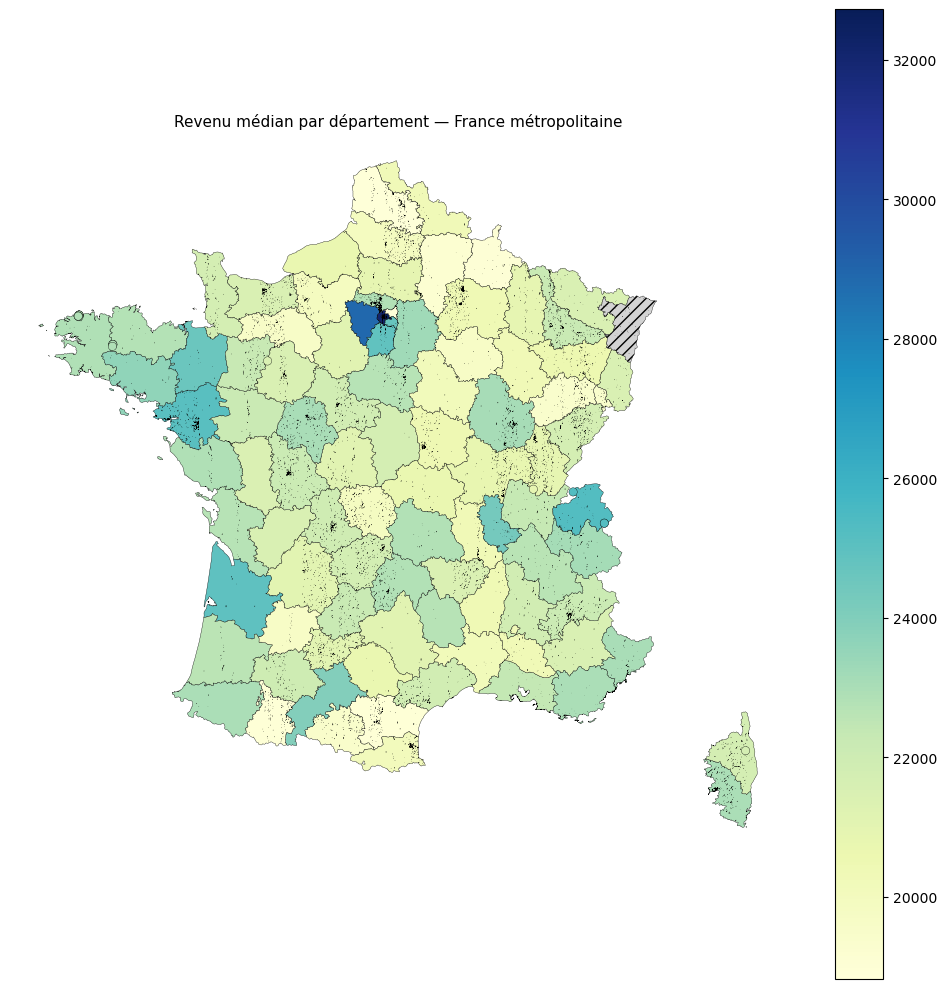

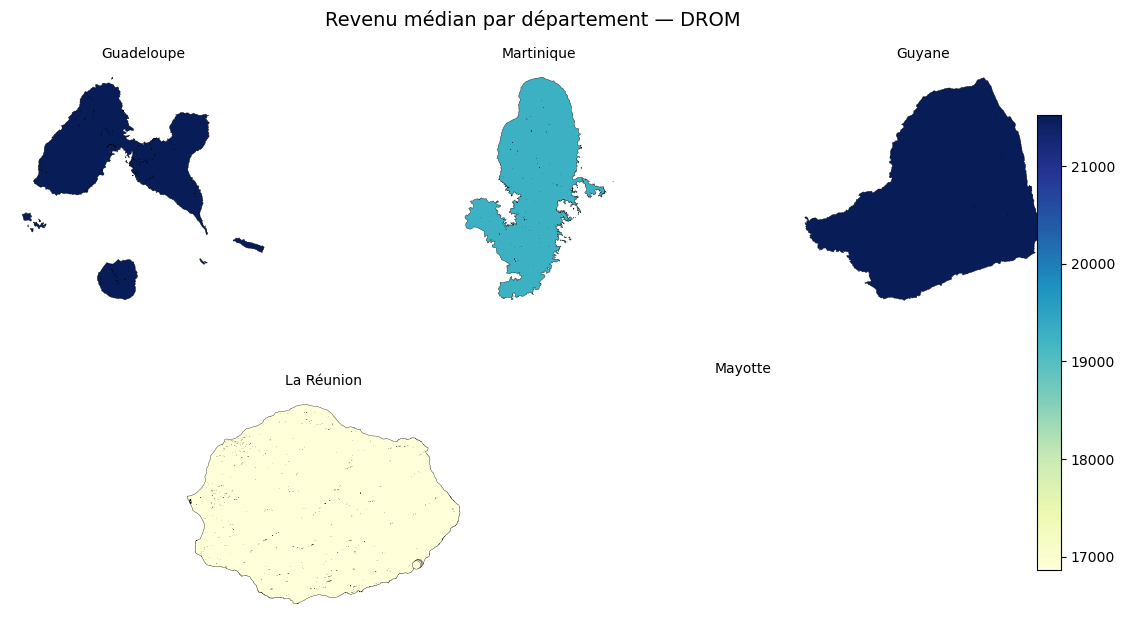

In [11]:
# Carte de contrôle — revenu médian FiLoSoFi.
# On vérifie que le signal socio-économique est spatialement cohérent et que les zones sans données restent visibles.
fig_paths = globals().get("fig_paths", [])
fig_paths += plot_department_indicator_maps(
    socle_iris,
    variable="revenu_median",
    title="Revenu médian par département",
    file_stub="filosofi_revenu_median",
    cmap="YlGnBu",
    aggfunc="median",
)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture économique des revenus médians par département</h3>
  <div style="color: #4b5563; font-size: 14px;">Les cartes mettent en évidence une forte hétérogénéité des revenus médians sur le territoire français. Les niveaux les plus élevés se concentrent principalement en Île-de-France, dans certaines métropoles régionales et sur plusieurs territoires littoraux attractifs. À l’inverse, plusieurs départements ruraux ou industriels présentent des revenus médians plus faibles, reflétant des structures économiques moins dynamiques. Les contrastes observés apparaissent cohérents avec les dynamiques immobilières : les territoires aux revenus élevés correspondent souvent aux zones où les prix au m² sont les plus importants. Cette relation reste toutefois partielle, certains marchés touristiques affichant des niveaux de prix élevés malgré des revenus locaux plus modestes. Les DROM présentent des profils spécifiques, avec des revenus médians globalement inférieurs à ceux observés en métropole et des écarts marqués entre territoires ultramarins. Ces variables socio-économiques constituent un enrichissement stratégique du pipeline. Elles permettront d’analyser les relations entre revenus, valorisation immobilière et tension résidentielle dans les futurs développements analytiques et prédictifs.</div>
</div>

In [12]:
# Enrichissement démographique INSEE : population et structure par âge, sans suppression des IRIS incomplets.
require_file(CONFIG["population"], "Fichier population INSEE")
population = read_table_auto(CONFIG["population"], "Fichier population INSEE", sep=";", low_memory=False)

pop_source_cols = ["IRIS", "COM", "P21_POP", "P21_PMEN", "P21_PHORMEN", "P21_POP1529", "P21_POP65P"]
require_columns(population, pop_source_cols, "population INSEE")

population = population[pop_source_cols].copy().rename(columns={
    "IRIS": "code_iris",
    "COM": "code_commune",
    "P21_POP": "population_2021",
    "P21_PMEN": "taille_menage_moyenne",
    "P21_PHORMEN": "population_hors_menages",
    "P21_POP1529": "population_15_29",
    "P21_POP65P": "population_65_plus",
})
population["code_iris"] = normalize_code_iris(population["code_iris"])
population["code_commune"] = normalize_code_commune(population["code_commune"])

for col in ["population_2021", "taille_menage_moyenne", "population_hors_menages", "population_15_29", "population_65_plus"]:
    population[col] = to_numeric_fr(population[col])

population["part_population_15_29"] = safe_divide(population["population_15_29"], population["population_2021"])
population["part_population_65_plus"] = safe_divide(population["population_65_plus"], population["population_2021"])

pop_vars = ["population_2021", "taille_menage_moyenne", "population_hors_menages", "part_population_15_29", "part_population_65_plus"]
population = population.groupby("code_iris", as_index=False)[pop_vars].median(numeric_only=True)

display(key_audit(population, "code_iris", "population_iris"))

socle_iris, mr, nr = audit_and_merge(socle_iris, population, "code_iris", pop_vars, "population_iris", validate="1:1")
merge_reports.append(mr); na_reports.append(nr)
socle_iris, dr = drop_rows_with_missing_added(socle_iris, pop_vars, "population_iris")
drop_reports.append(dr)

display(mr); display(nr); display(dr)
print("Shape socle après population :", socle_iris.shape)


,source,key,rows,non_null_key,unique_key,duplicated_key
0,population_iris,code_iris,49280,49280,49280,0


,source,join_key,rows_before,rows_after_merge,matched_rows,unmatched_rows,match_rate,added_cols
0,population_iris,code_iris,47790,47790,45972,1818,0.961959,"population_2021, taille_menage_moyenne, popula..."


,source,variable,missing_after_merge,missing_rate_after_merge
0,population_iris,population_2021,1818,0.038041
1,population_iris,taille_menage_moyenne,1818,0.038041
2,population_iris,population_hors_menages,1818,0.038041
3,population_iris,part_population_15_29,1831,0.038313
4,population_iris,part_population_65_plus,1831,0.038313


,source,rule,columns_checked,rows_before,rows_dropped,rows_after,drop_rate,max_missing_in_cols,min_missing_in_cols,max_missing_rate
0,population_iris,no_drop_preserve_all_iris,"population_2021, taille_menage_moyenne, popula...",47790,0,47790,0.0,1831,1818,0.038313


Shape socle après population : (47790, 24)


Aucun fond départemental exploitable trouvé : reconstruction depuis le fond IRIS avec réparation géométrique.
Réparation IRIS vers départements : 6984 géométrie(s) invalide(s) détectée(s).
Carte population_2021 : 99 départements avec une valeur agrégée.


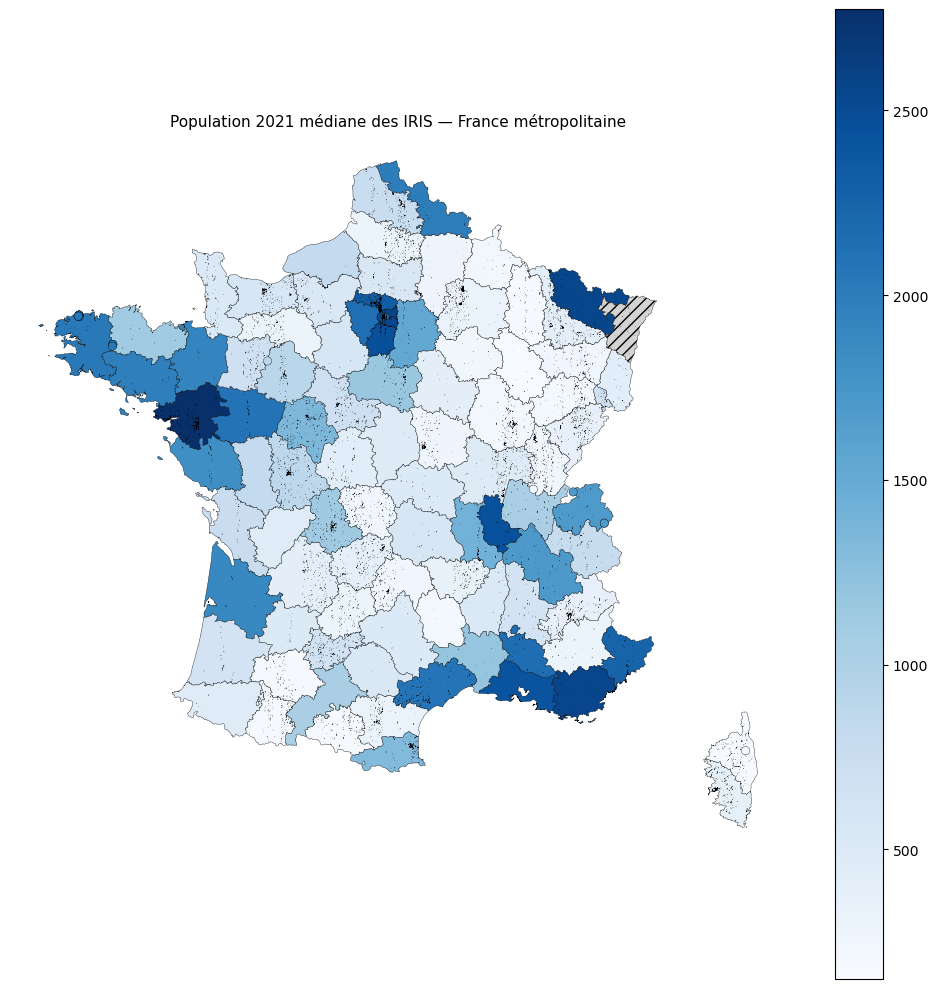

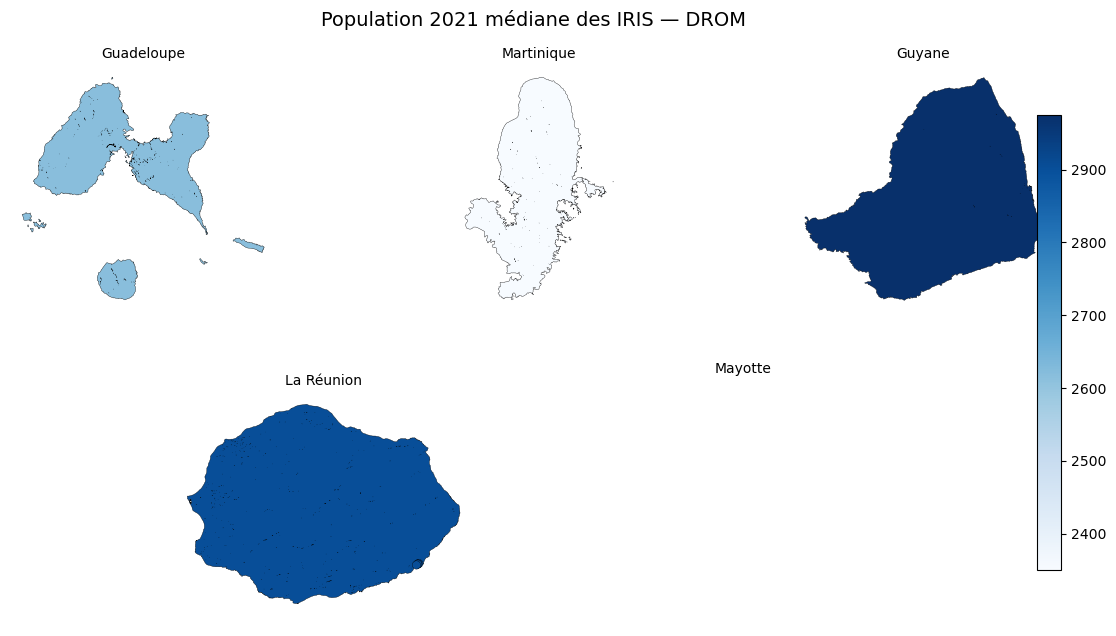

In [13]:
# Carte de contrôle — population.
# Cette carte met en évidence les masses démographiques qui structurent la pression locale.
fig_paths = globals().get("fig_paths", [])
fig_paths += plot_department_indicator_maps(
    socle_iris,
    variable="population_2021",
    title="Population 2021 médiane des IRIS",
    file_stub="population_2021",
    cmap="Blues",
    aggfunc="median",
)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture démographique des populations médianes par IRIS</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes mettent en évidence une forte hétérogénéité démographique entre les territoires français. Les niveaux de population les plus élevés se concentrent principalement autour des grandes métropoles, des zones littorales attractives et des principaux bassins économiques. L’Île-de-France, l’arc méditerranéen et plusieurs métropoles régionales ressortent nettement, tandis que certains départements ruraux du centre de la France présentent des densités de population plus faibles et un habitat plus dispersé. Les dynamiques observées apparaissent cohérentes avec les volumes de transactions, les revenus médians et les niveaux de prix immobiliers analysés précédemment. Les territoires les plus dynamiques sur le plan démographique concentrent généralement davantage de mutations et des prix au m² plus élevés. Les DROM présentent des profils différenciés. La Guyane et La Réunion affichent des niveaux de population relativement élevés, tandis que la Martinique présente une structure démographique plus modérée. Ces enrichissements démographiques constituent un levier important pour les futurs développements analytiques. Ils permettront de mieux contextualiser les dynamiques de prix, d’identifier les zones de tension résidentielle et d’améliorer les futurs modèles prédictifs territoriaux.</div>
</div>

In [14]:
# Enrichissement structure du parc logement INSEE avec contrôle qualité non destructif.
require_file(CONFIG["logement"], "Fichier logement INSEE")
logement = read_table_auto(CONFIG["logement"], "Fichier logement INSEE", sep=";")

log_source_cols = ["IRIS", "COM", "P22_LOG", "P22_RP", "P22_RSECOCC", "P22_LOGVAC", "P22_MAISON", "P22_APPART"]
require_columns(logement, log_source_cols, "logement INSEE")

logement = logement[log_source_cols].copy().rename(columns={
    "IRIS": "code_iris",
    "COM": "code_commune",
    "P22_LOG": "nb_logements_2022",
    "P22_RP": "nb_residences_principales",
    "P22_RSECOCC": "nb_residences_secondaires",
    "P22_LOGVAC": "nb_logements_vacants",
    "P22_MAISON": "nb_maisons",
    "P22_APPART": "nb_appartements",
})
logement["code_iris"] = normalize_code_iris(logement["code_iris"])
logement["code_commune"] = normalize_code_commune(logement["code_commune"])

for col in ["nb_logements_2022", "nb_residences_principales", "nb_residences_secondaires", "nb_logements_vacants", "nb_maisons", "nb_appartements"]:
    logement[col] = to_numeric_fr(logement[col])

logement["part_residences_principales"] = safe_divide(logement["nb_residences_principales"], logement["nb_logements_2022"])
logement["part_residences_secondaires"] = safe_divide(logement["nb_residences_secondaires"], logement["nb_logements_2022"])
logement["part_logements_vacants"] = safe_divide(logement["nb_logements_vacants"], logement["nb_logements_2022"])
logement["part_maisons"] = safe_divide(logement["nb_maisons"], logement["nb_logements_2022"])
logement["part_appartements"] = safe_divide(logement["nb_appartements"], logement["nb_logements_2022"])

logement_vars = [
    "nb_logements_2022", "part_residences_principales", "part_residences_secondaires",
    "part_logements_vacants", "part_maisons", "part_appartements"
]
logement = logement.groupby("code_iris", as_index=False)[logement_vars].median(numeric_only=True)

display(key_audit(logement, "code_iris", "logement_iris"))

socle_iris, mr, nr = audit_and_merge(socle_iris, logement, "code_iris", logement_vars, "logement_iris", validate="1:1")
merge_reports.append(mr); na_reports.append(nr)
socle_iris, dr = drop_rows_with_missing_added(socle_iris, logement_vars, "logement_iris")
drop_reports.append(dr)

display(mr); display(nr); display(dr)
print("Shape socle après logement :", socle_iris.shape)


,source,key,rows,non_null_key,unique_key,duplicated_key
0,logement_iris,code_iris,49276,49276,49276,0


,source,join_key,rows_before,rows_after_merge,matched_rows,unmatched_rows,match_rate,added_cols
0,logement_iris,code_iris,47790,47790,45950,1840,0.961498,"nb_logements_2022, part_residences_principales..."


,source,variable,missing_after_merge,missing_rate_after_merge
0,logement_iris,nb_logements_2022,1840,0.038502
1,logement_iris,part_residences_principales,1849,0.038690
2,logement_iris,part_residences_secondaires,1849,0.038690
3,logement_iris,part_logements_vacants,1849,0.038690
4,logement_iris,part_maisons,1849,0.038690
5,logement_iris,part_appartements,1849,0.038690


,source,rule,columns_checked,rows_before,rows_dropped,rows_after,drop_rate,max_missing_in_cols,min_missing_in_cols,max_missing_rate
0,logement_iris,no_drop_preserve_all_iris,"nb_logements_2022, part_residences_principales...",47790,0,47790,0.0,1849,1840,0.03869


Shape socle après logement : (47790, 30)


Aucun fond départemental exploitable trouvé : reconstruction depuis le fond IRIS avec réparation géométrique.
Réparation IRIS vers départements : 6984 géométrie(s) invalide(s) détectée(s).
Carte part_logements_vacants : 99 départements avec une valeur agrégée.


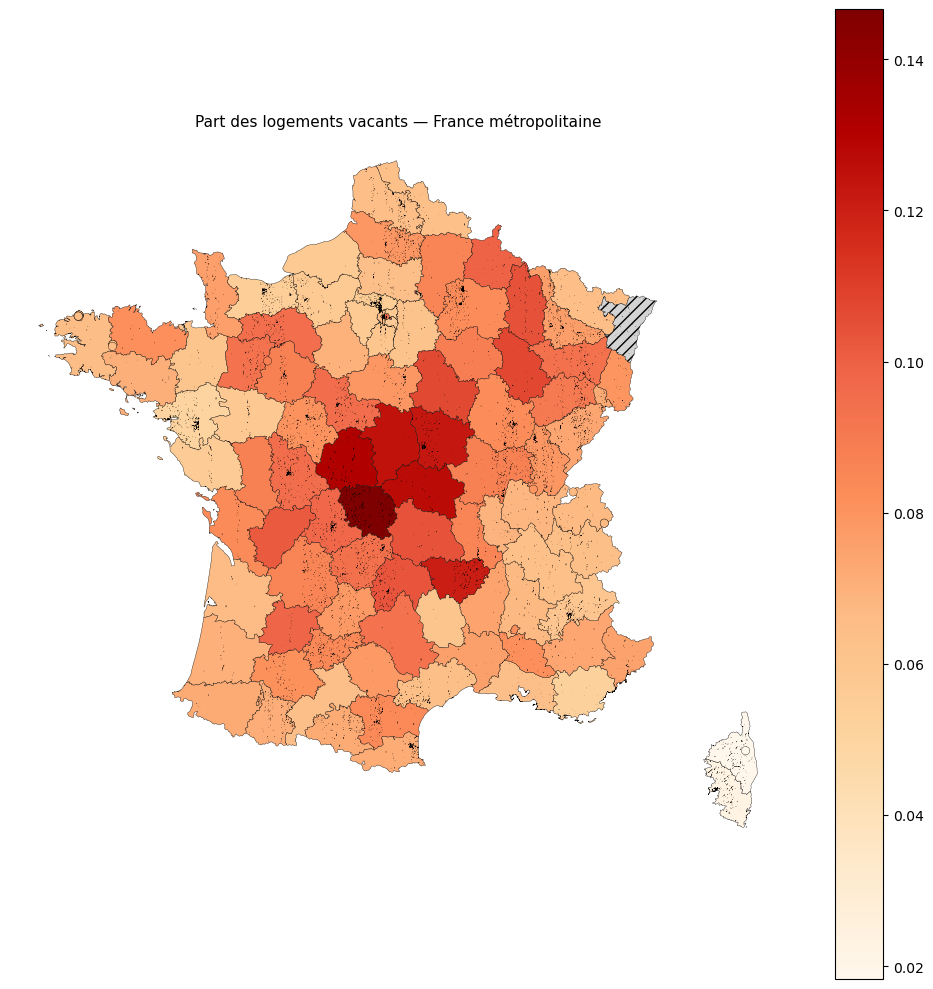

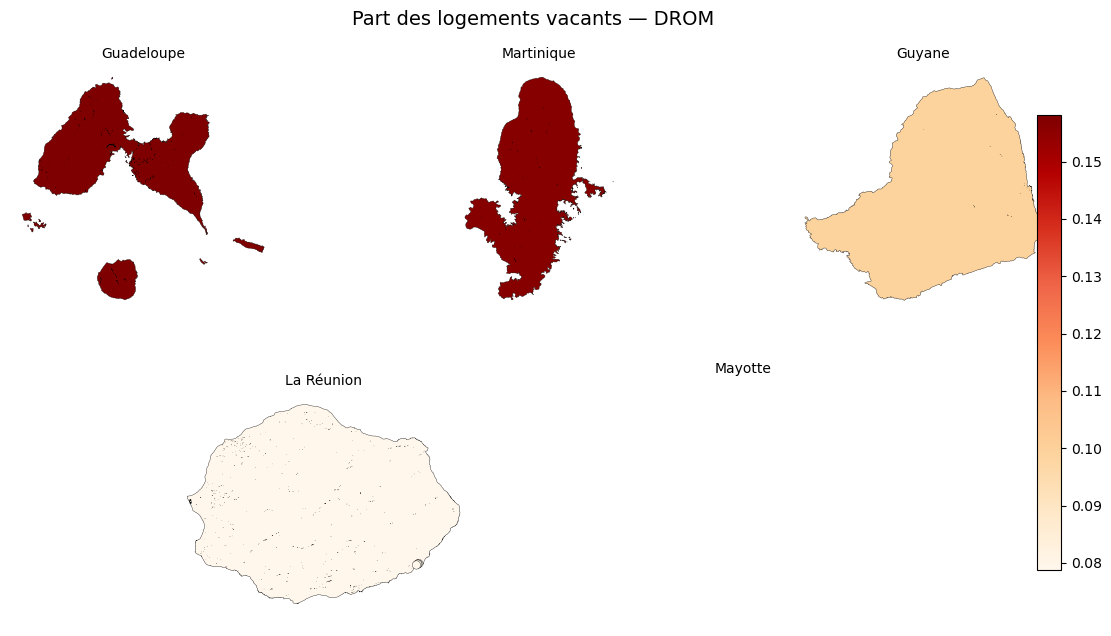

Aucun fond départemental exploitable trouvé : reconstruction depuis le fond IRIS avec réparation géométrique.
Réparation IRIS vers départements : 6984 géométrie(s) invalide(s) détectée(s).
Carte part_residences_secondaires : 99 départements avec une valeur agrégée.


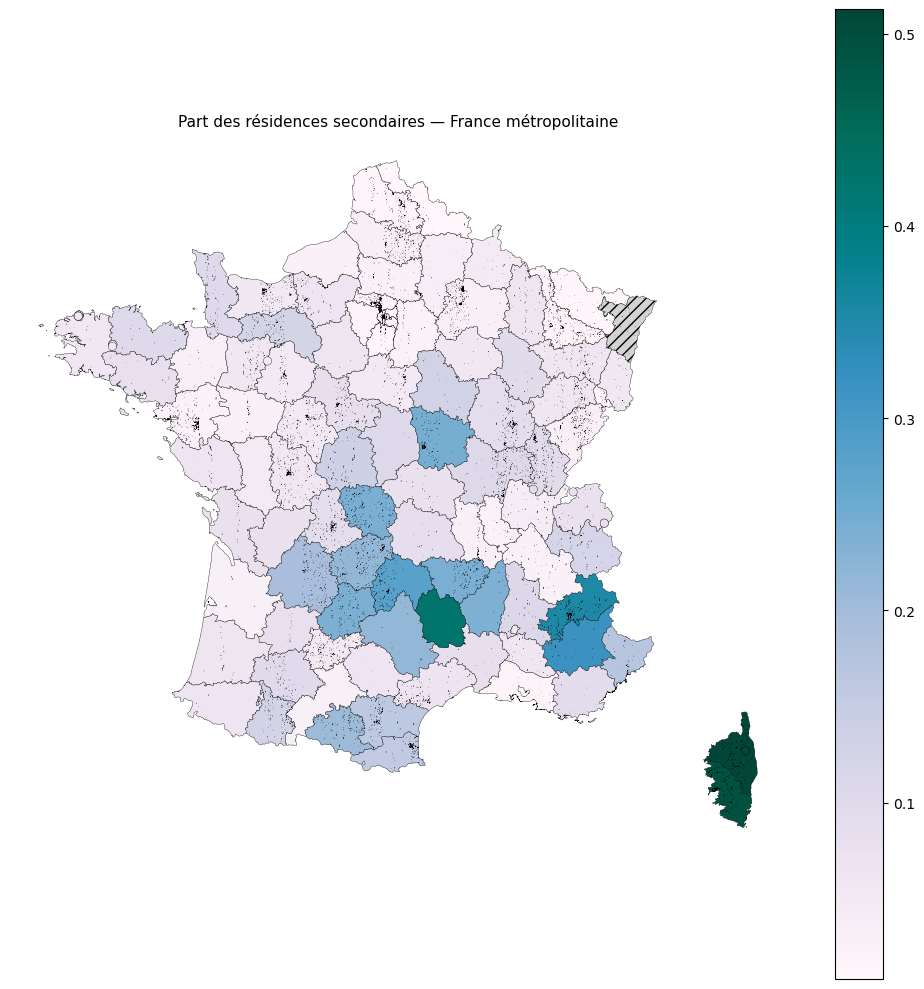

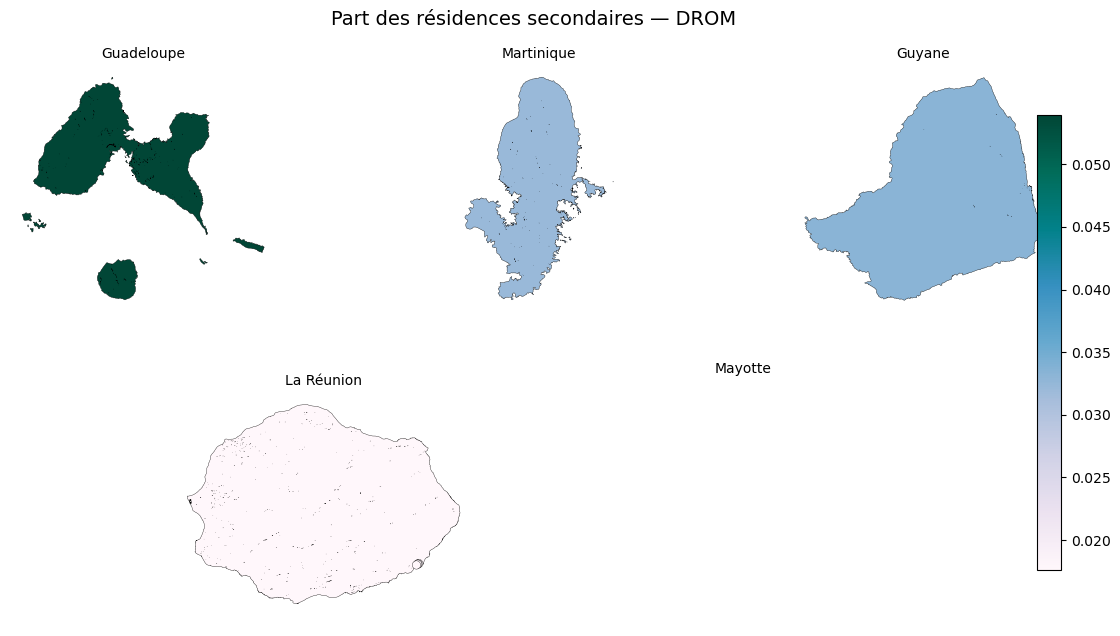

In [15]:
# Cartes de contrôle — structure du parc immobilier.
# La vacance et les résidences secondaires aident à repérer les marchés tendus, touristiques ou moins liquides.
fig_paths = globals().get("fig_paths", [])
fig_paths += plot_department_indicator_maps(
    socle_iris,
    variable="part_logements_vacants",
    title="Part des logements vacants",
    file_stub="logement_part_vacance",
    cmap="OrRd",
    aggfunc="median",
)
fig_paths += plot_department_indicator_maps(
    socle_iris,
    variable="part_residences_secondaires",
    title="Part des résidences secondaires",
    file_stub="logement_part_residences_secondaires",
    cmap="PuBuGn",
    aggfunc="median",
)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture territoriale de la vacance des logements</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes mettent en évidence une forte différenciation territoriale des taux de vacance résidentielle. Cet indicateur constitue un signal important des dynamiques locales du marché immobilier, en lien avec l’attractivité résidentielle, la tension foncière et l’équilibre entre offre et demande de logements. Plusieurs départements ruraux ou en perte de dynamisme présentent des niveaux de vacance relativement élevés, notamment dans le centre de la France. Ces situations peuvent refléter des fragilités démographiques, une attractivité économique plus limitée ou un déséquilibre structurel du parc résidentiel. À l’inverse, les grandes métropoles et les territoires littoraux les plus attractifs affichent généralement des taux de vacance plus faibles, cohérents avec une pression résidentielle soutenue et des marchés immobiliers plus tendus. Les dynamiques observées apparaissent globalement cohérentes avec les niveaux de revenus, les prix immobiliers et les volumes de transactions étudiés précédemment. Les territoires les plus valorisés économiquement tendent également à présenter une vacance plus limitée. Les DROM présentent des profils plus contrastés. La Guadeloupe et la Martinique affichent des taux de vacance relativement élevés, tandis que La Réunion et la Guyane apparaissent moins concernées, en cohérence avec leurs dynamiques démographiques plus soutenues. Cet indicateur constituera un enrichissement structurant pour les futures analyses territoriales, notamment dans l’étude des marchés tendus, des dynamiques de décroissance résidentielle et des futurs modèles prédictifs immobiliers. L’interprétation doit toutefois rester prudente : un niveau élevé de vacance peut également refléter des résidences secondaires, des logements touristiques, des biens temporairement inoccupés ou certaines spécificités locales du parc immobilier.</div>
</div>

In [16]:
# Enrichissement BPE (niveau IRIS prioritaire, sinon commune), avec conservation des lignes incomplètes.
require_file(CONFIG["bpe"], "Fichier BPE")

try:
    bpe = pd.read_parquet(CONFIG["bpe"])
except Exception:
    import duckdb
    con = duckdb.connect()
    cols = [row[0] for row in con.execute(f"describe select * from read_parquet('{CONFIG['bpe'].as_posix()}')").fetchall()]
    selected_cols = [c for c in ["DCIRIS", "IRISEE", "DEPCOM"] if c in cols]
    if not selected_cols:
        raise ValueError("Aucune colonne géographique exploitable dans la BPE.")
    bpe = con.execute(f"select {', '.join(selected_cols)} from read_parquet('{CONFIG['bpe'].as_posix()}')").fetchdf()

if "DCIRIS" in bpe.columns:
    bpe["code_iris"] = normalize_code_iris(bpe["DCIRIS"])
    bpe_agg = bpe.groupby("code_iris").size().reset_index(name="nb_equipements_bpe")
    join_key = "code_iris"
    source_name = "bpe_iris"
elif "IRISEE" in bpe.columns:
    bpe["code_iris"] = normalize_code_iris(bpe["IRISEE"])
    bpe_agg = bpe.groupby("code_iris").size().reset_index(name="nb_equipements_bpe")
    join_key = "code_iris"
    source_name = "bpe_iris"
elif "DEPCOM" in bpe.columns:
    bpe["code_commune"] = normalize_code_commune(bpe["DEPCOM"])
    bpe_agg = bpe.groupby("code_commune").size().reset_index(name="nb_equipements_bpe")
    join_key = "code_commune"
    source_name = "bpe_commune"
else:
    raise ValueError("BPE : aucune clé parmi DCIRIS, IRISEE ou DEPCOM.")

bpe_vars = ["nb_equipements_bpe"]
display(key_audit(bpe_agg, join_key, source_name))

socle_iris, mr, nr = audit_and_merge(socle_iris, bpe_agg, join_key, bpe_vars, source_name, validate="m:1")
merge_reports.append(mr); na_reports.append(nr)
socle_iris, dr = drop_rows_with_missing_added(socle_iris, bpe_vars, source_name)
drop_reports.append(dr)

display(mr); display(nr); display(dr)
print("Shape socle après BPE :", socle_iris.shape)


,source,key,rows,non_null_key,unique_key,duplicated_key
0,bpe_iris,code_iris,51164,51164,51164,0


,source,join_key,rows_before,rows_after_merge,matched_rows,unmatched_rows,match_rate,added_cols
0,bpe_iris,code_iris,47790,47790,45940,1850,0.961289,nb_equipements_bpe


,source,variable,missing_after_merge,missing_rate_after_merge
0,bpe_iris,nb_equipements_bpe,1850,0.038711


,source,rule,columns_checked,rows_before,rows_dropped,rows_after,drop_rate,max_missing_in_cols,min_missing_in_cols,max_missing_rate
0,bpe_iris,no_drop_preserve_all_iris,nb_equipements_bpe,47790,0,47790,0.0,1850,1850,0.038711


Shape socle après BPE : (47790, 31)


Aucun fond départemental exploitable trouvé : reconstruction depuis le fond IRIS avec réparation géométrique.
Réparation IRIS vers départements : 6984 géométrie(s) invalide(s) détectée(s).
Carte nb_equipements_bpe : 99 départements avec une valeur agrégée.


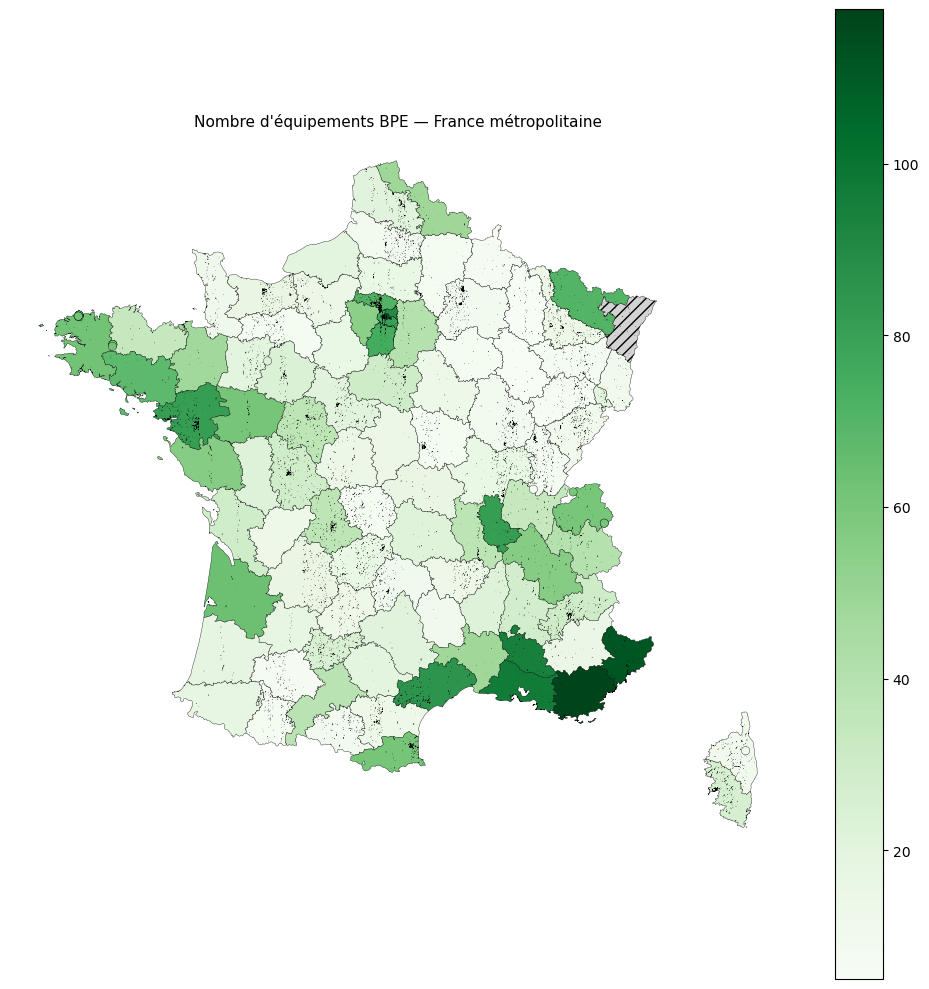

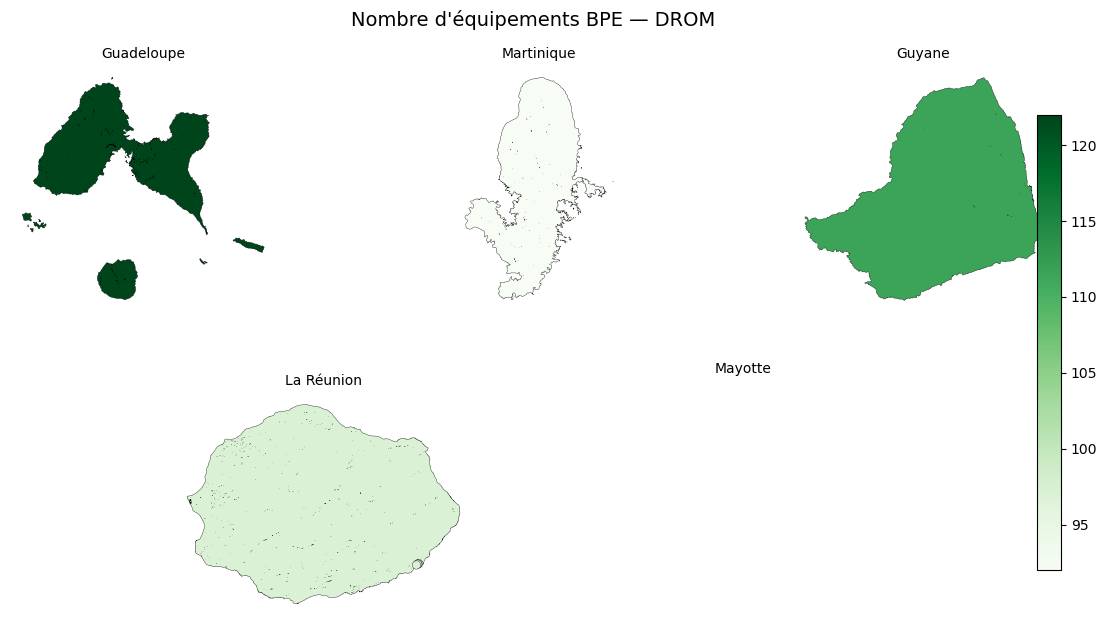

In [17]:
# Carte de contrôle — équipements BPE.
# Le nombre d'équipements donne un proxy simple de centralité et d'accès aux services.
fig_paths = globals().get("fig_paths", [])
fig_paths += plot_department_indicator_maps(
    socle_iris,
    variable="nb_equipements_bpe",
    title="Nombre d'équipements BPE",
    file_stub="bpe_nb_equipements",
    cmap="Greens",
    aggfunc="median",
)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture territoriale des équipements BPE</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes mettent en évidence de fortes disparités territoriales dans la répartition des équipements BPE. Cet indicateur constitue un proxy pertinent du niveau de services, de l’intensité urbaine et de l’attractivité résidentielle des territoires. Les niveaux d’équipements les plus élevés se concentrent principalement dans les grandes métropoles, les territoires densément urbanisés et plusieurs zones littorales attractives. Ces espaces cumulent généralement densité de population, activité économique et offre de services plus développée. À l’inverse, plusieurs départements ruraux présentent des niveaux d’équipements plus faibles, cohérents avec une moindre densité démographique et un tissu économique plus diffus. Les dynamiques observées apparaissent globalement cohérentes avec les indicateurs analysés précédemment : les territoires les mieux équipés correspondent souvent aux zones les plus attractives résidentiellement, aux marchés immobiliers les plus dynamiques et aux niveaux de prix les plus élevés. Les DROM présentent des profils plus contrastés. La Guadeloupe et la Guyane affichent des niveaux d’équipements relativement élevés, traduisant une concentration des services autour des principaux pôles urbains, tandis que La Réunion et la Martinique apparaissent plus modérées dans cette agrégation départementale. Cet enrichissement constitue un apport structurant pour les futures analyses territoriales. Les indicateurs BPE permettront d’étudier plus finement l’attractivité locale, les déterminants des prix immobiliers et les dynamiques de valorisation résidentielle. L’interprétation doit toutefois rester prudente : cette représentation agrégée à l’échelle départementale masque une partie importante des disparités locales, qui apparaîtront davantage lors des analyses fines au niveau IRIS.</div>
</div>

In [18]:
# Enrichissement énergétique ADEME (DPE) agrégé à la commune, avec creation d'un flag de disponibilite.
require_file(CONFIG["dpe_neuf"], "DPE logements neufs")
require_file(CONFIG["dpe_existant"], "DPE logements existants")

dpe_neuf = pd.read_csv(CONFIG["dpe_neuf"], low_memory=False)
dpe_existant = pd.read_csv(CONFIG["dpe_existant"], low_memory=False)
dpe = pd.concat([dpe_neuf, dpe_existant], ignore_index=True)

require_columns(dpe, ["code_insee_ban", "etiquette_dpe"], "DPE ADEME")
dpe["code_commune"] = normalize_code_commune(dpe["code_insee_ban"])
score_map = {"A": 7, "B": 6, "C": 5, "D": 4, "E": 3, "F": 2, "G": 1}
dpe["etiquette_dpe_norm"] = dpe["etiquette_dpe"].astype("string").str.upper().str.strip()
dpe["score_dpe"] = dpe["etiquette_dpe_norm"].map(score_map)

dpe_commune = (
    dpe.dropna(subset=["code_commune"])
    .groupby("code_commune")
    .agg(
        nb_dpe=("score_dpe", "count"),
        score_dpe_moyen=("score_dpe", "mean"),
        part_dpe_ab=("etiquette_dpe_norm", lambda x: x.isin(["A", "B"]).mean()),
        part_dpe_fg=("etiquette_dpe_norm", lambda x: x.isin(["F", "G"]).mean()),
    )
    .reset_index()
)

dpe_metric_vars = ["nb_dpe", "score_dpe_moyen", "part_dpe_ab", "part_dpe_fg"]
display(key_audit(dpe_commune, "code_commune", "dpe_commune"))

socle_iris, mr, nr = audit_and_merge(socle_iris, dpe_commune, "code_commune", dpe_metric_vars, "dpe_commune", validate="m:1")
merge_reports.append(mr); na_reports.append(nr)
socle_iris["dpe_available"] = socle_iris["nb_dpe"].notna().astype("int8")
dpe_vars = dpe_metric_vars + ["dpe_available"]
socle_iris, dr = drop_rows_with_missing_added(socle_iris, dpe_vars, "dpe_commune")
drop_reports.append(dr)

display(mr); display(nr); display(dr)
print("Shape socle après DPE :", socle_iris.shape)


,source,key,rows,non_null_key,unique_key,duplicated_key
0,dpe_commune,code_commune,35402,35402,35402,0


,source,join_key,rows_before,rows_after_merge,matched_rows,unmatched_rows,match_rate,added_cols
0,dpe_commune,code_commune,47790,47790,46113,1677,0.964909,"nb_dpe, score_dpe_moyen, part_dpe_ab, part_dpe_fg"


,source,variable,missing_after_merge,missing_rate_after_merge
0,dpe_commune,nb_dpe,1677,0.035091
1,dpe_commune,score_dpe_moyen,1677,0.035091
2,dpe_commune,part_dpe_ab,1677,0.035091
3,dpe_commune,part_dpe_fg,1677,0.035091


,source,rule,columns_checked,rows_before,rows_dropped,rows_after,drop_rate,max_missing_in_cols,min_missing_in_cols,max_missing_rate
0,dpe_commune,no_drop_preserve_all_iris,"nb_dpe, score_dpe_moyen, part_dpe_ab, part_dpe...",47790,0,47790,0.0,1677,0,0.035091


Shape socle après DPE : (47790, 36)


Aucun fond départemental exploitable trouvé : reconstruction depuis le fond IRIS avec réparation géométrique.
Réparation IRIS vers départements : 6984 géométrie(s) invalide(s) détectée(s).
Carte score_dpe_moyen : 99 départements avec une valeur agrégée.


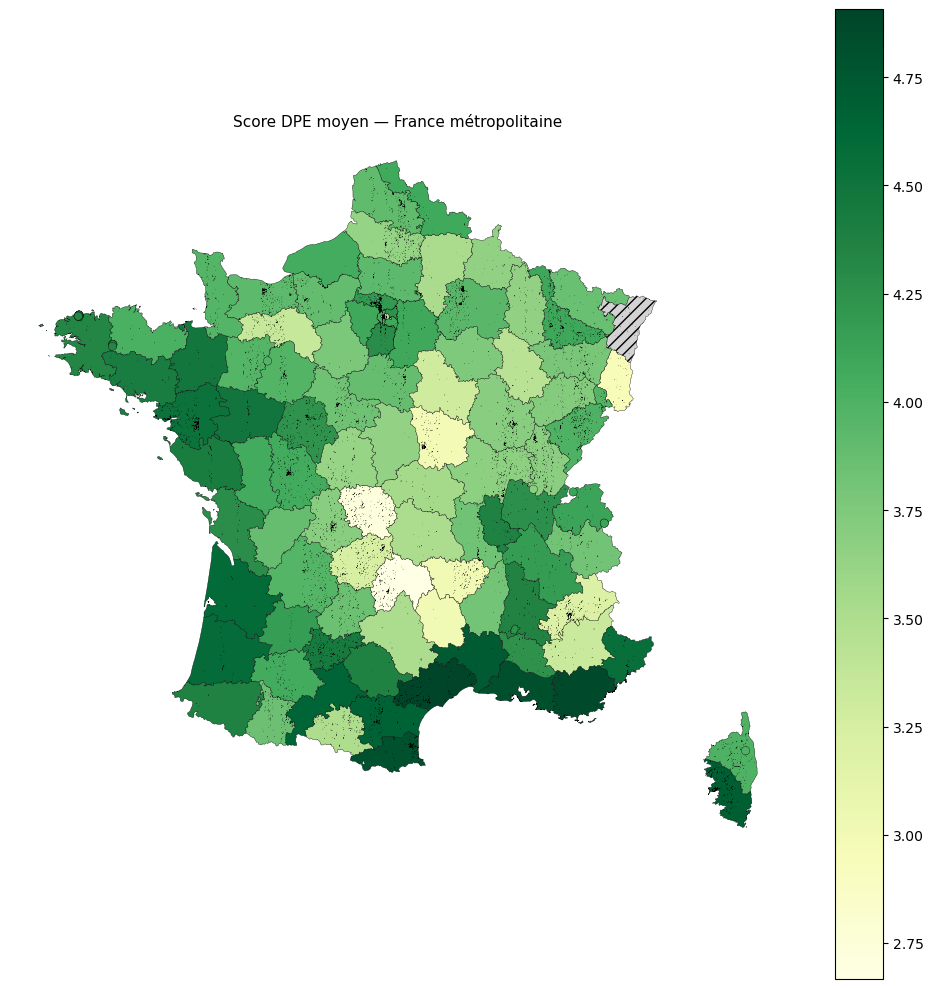

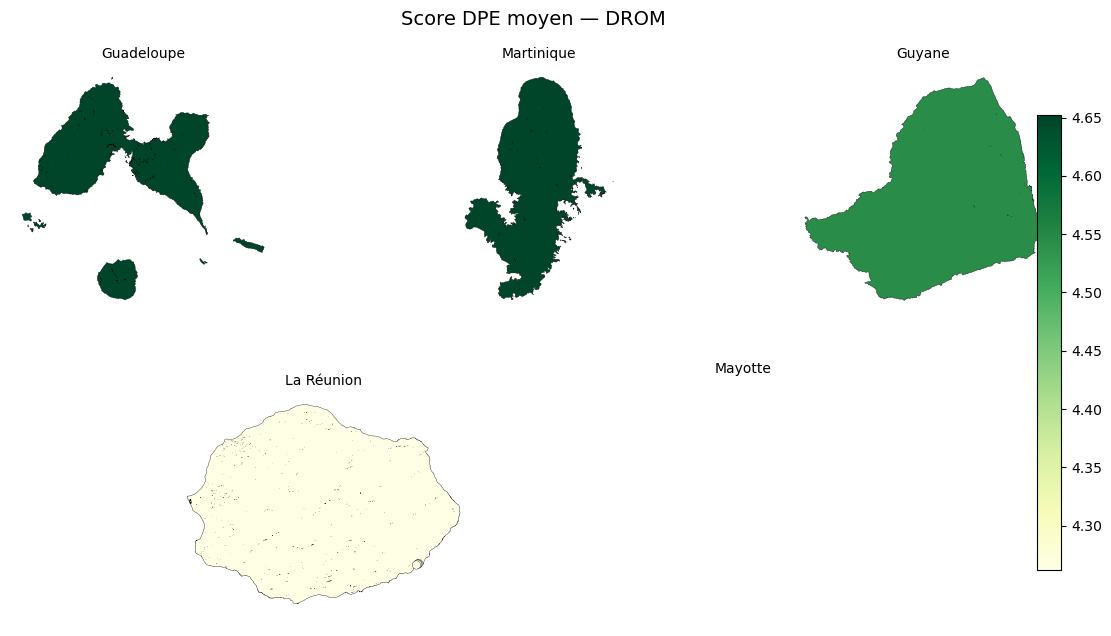

Carte non produite : variable absente (dpe_missing_flag).


In [19]:
# Cartes de contrôle — signal DPE.
# Le score DPE décrit le signal énergétique disponible ; le flag signale les communes sans données exploitables.
fig_paths = globals().get("fig_paths", [])
fig_paths += plot_department_indicator_maps(
    socle_iris,
    variable="score_dpe_moyen",
    title="Score DPE moyen",
    file_stub="dpe_score_moyen",
    cmap="YlGn",
    aggfunc="median",
)
fig_paths += plot_department_indicator_maps(
    socle_iris,
    variable="dpe_missing_flag",
    title="Part des IRIS sans signal DPE",
    file_stub="dpe_missing_flag",
    cmap="Reds",
    aggfunc="mean",
)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture territoriale des scores DPE moyens</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette carte met en évidence des disparités territoriales importantes des scores DPE moyens à l’échelle départementale. Le DPE constitue un indicateur structurant de la qualité énergétique du parc résidentiel. Les écarts observés reflètent plusieurs facteurs : ancienneté du parc immobilier, conditions climatiques, typologie des logements, niveau de rénovation énergétique et poids des maisons individuelles. Plusieurs départements du sud et de l’ouest présentent des scores moyens plus élevés, cohérents avec des besoins de chauffage plus limités et un parc parfois plus récent ou davantage rénové. À l’inverse, certains territoires du centre et du nord-est affichent des scores plus faibles, en lien avec un parc résidentiel plus ancien et des contraintes climatiques plus marquées. Les dynamiques observées suggèrent également une relation croissante entre qualité énergétique, attractivité résidentielle et valorisation immobilière. La performance énergétique devient progressivement un facteur différenciant du marché immobilier. Les DROM présentent des profils spécifiques, avec des scores généralement plus élevés, probablement liés aux caractéristiques climatiques locales et à des besoins énergétiques différents de ceux observés en métropole. L’interprétation doit toutefois rester prudente : les comparaisons territoriales peuvent être influencées par les méthodes de calcul du DPE, les spécificités climatiques et l’hétérogénéité des données disponibles. Cet enrichissement énergétique constituera un levier important pour les futures analyses territoriales et les modèles de valorisation immobilière.</div>
</div>

In [20]:
# Construction des densités territoriales dérivées et application de la règle de complétude.
constructed_vars = []

if {"population_2021", "surface_iris_km2"}.issubset(socle_iris.columns):
    socle_iris["densite_population_km2"] = safe_divide(socle_iris["population_2021"], socle_iris["surface_iris_km2"])
    constructed_vars.append("densite_population_km2")

if {"nb_logements_2022", "surface_iris_km2"}.issubset(socle_iris.columns):
    socle_iris["densite_logements_km2"] = safe_divide(socle_iris["nb_logements_2022"], socle_iris["surface_iris_km2"])
    constructed_vars.append("densite_logements_km2")

if constructed_vars:
    socle_iris, dr = drop_rows_with_missing_added(socle_iris, constructed_vars, "variables_construites")
    drop_reports.append(dr)
    display(dr)

print("Variables construites :", constructed_vars)
print("Shape socle après variables construites :", socle_iris.shape)


,source,rule,columns_checked,rows_before,rows_dropped,rows_after,drop_rate,max_missing_in_cols,min_missing_in_cols,max_missing_rate
0,variables_construites,no_drop_preserve_all_iris,"densite_population_km2, densite_logements_km2",47790,0,47790,0.0,1840,1818,0.038502


Variables construites : ['densite_population_km2', 'densite_logements_km2']
Shape socle après variables construites : (47790, 38)


Aucun fond départemental exploitable trouvé : reconstruction depuis le fond IRIS avec réparation géométrique.
Réparation IRIS vers départements : 6984 géométrie(s) invalide(s) détectée(s).
Carte densite_population_km2 : 99 départements avec une valeur agrégée.


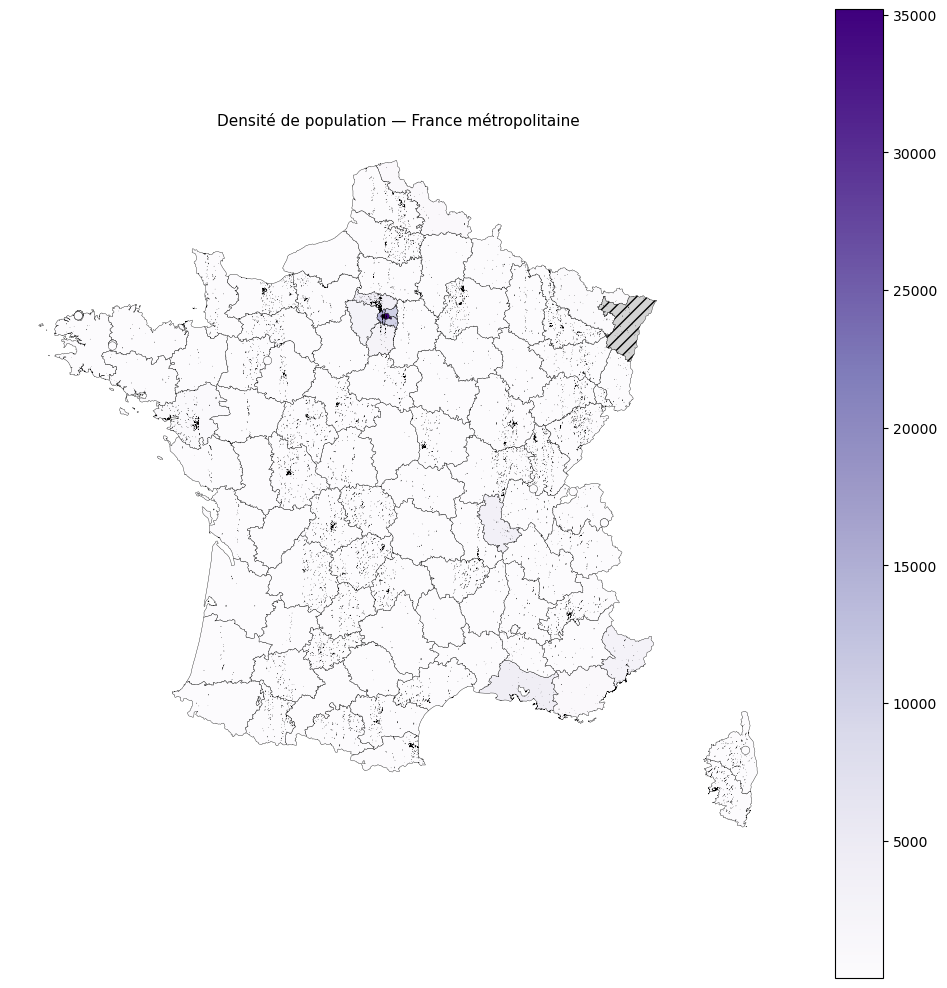

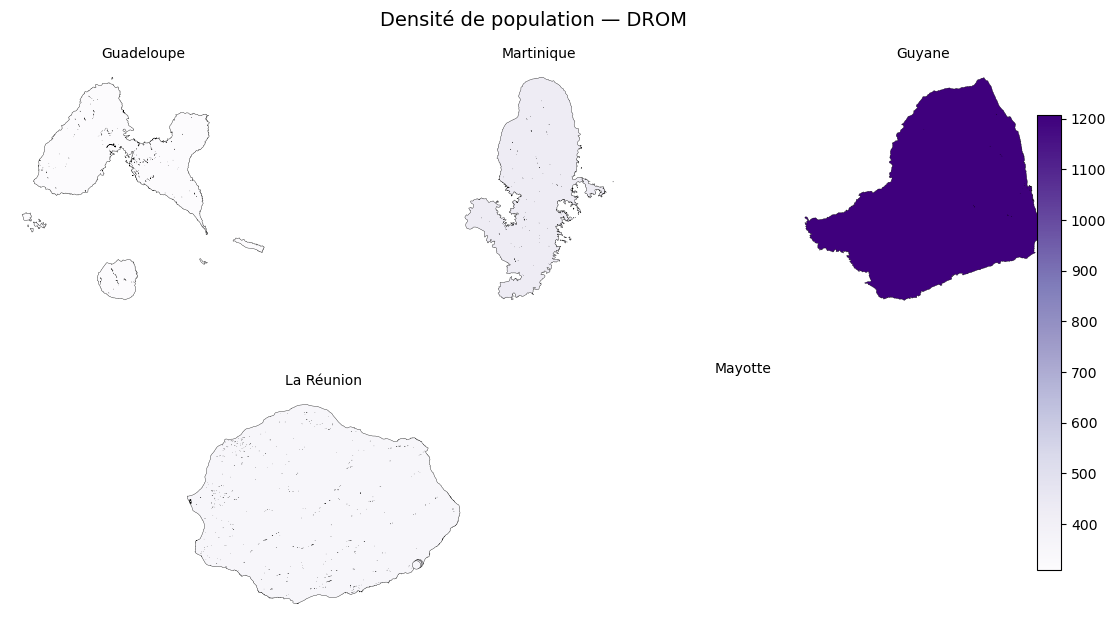

Aucun fond départemental exploitable trouvé : reconstruction depuis le fond IRIS avec réparation géométrique.
Réparation IRIS vers départements : 6984 géométrie(s) invalide(s) détectée(s).
Carte densite_logements_km2 : 99 départements avec une valeur agrégée.


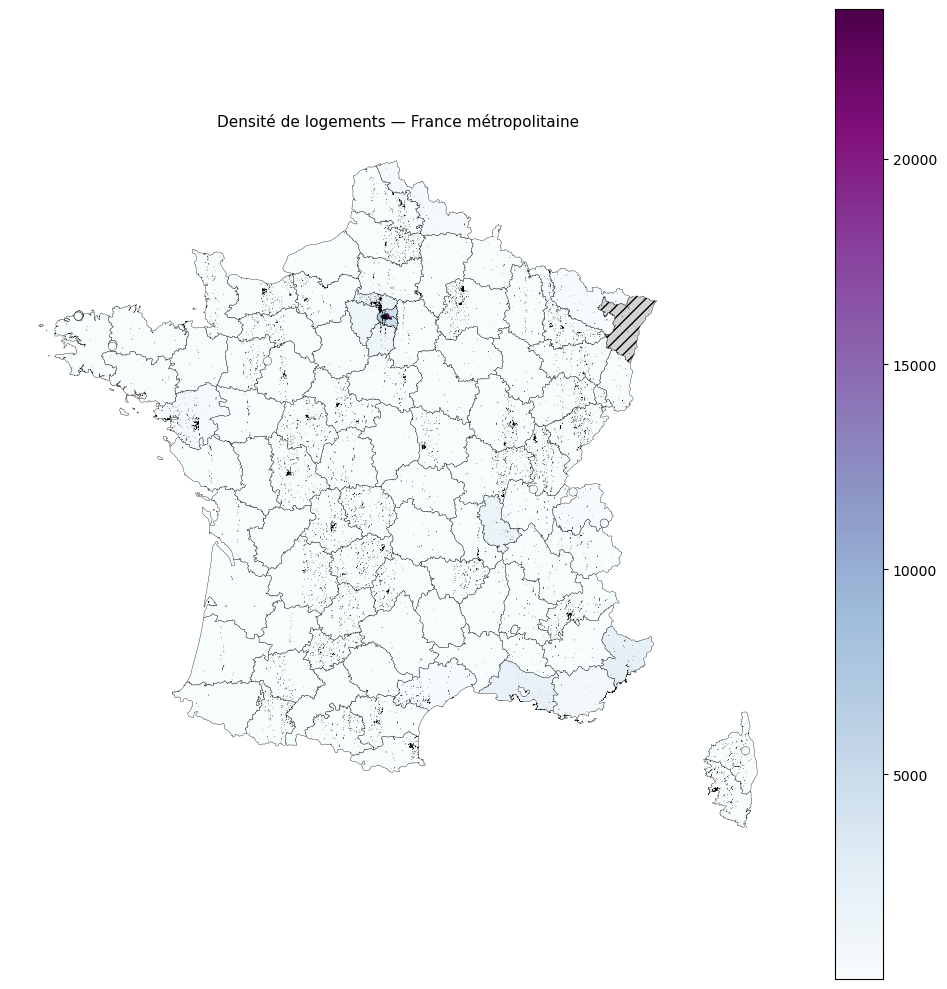

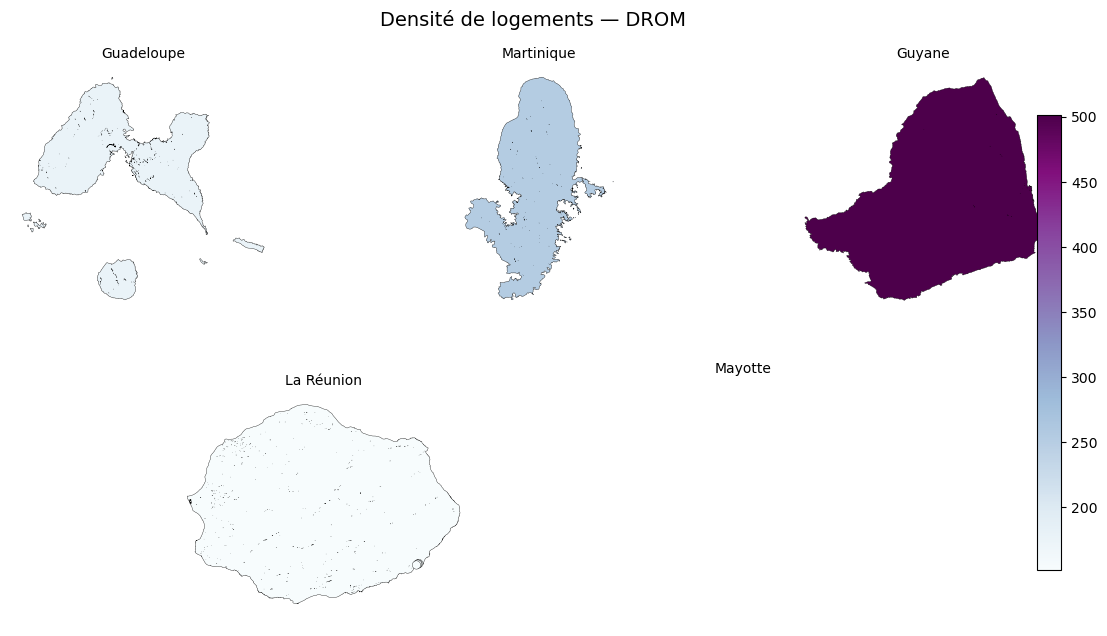

In [21]:
# Cartes de contrôle — densités construites.
# Les densités résument la pression d'occupation et la forme urbaine locale.
fig_paths = globals().get("fig_paths", [])
if "densite_population_km2" in socle_iris.columns:
    fig_paths += plot_department_indicator_maps(
        socle_iris,
        variable="densite_population_km2",
        title="Densité de population",
        file_stub="densite_population",
        cmap="Purples",
        aggfunc="median",
    )
if "densite_logements_km2" in socle_iris.columns:
    fig_paths += plot_department_indicator_maps(
        socle_iris,
        variable="densite_logements_km2",
        title="Densité de logements",
        file_stub="densite_logements",
        cmap="BuPu",
        aggfunc="median",
    )

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture territoriale des densités de population et de logements</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes mettent en évidence une forte concentration de la population et du parc résidentiel autour des principaux espaces urbains français. L’Île-de-France se distingue nettement par des niveaux de densité très supérieurs au reste du territoire. Les densités de population et de logements présentent des dynamiques spatiales proches, traduisant la concentration simultanée des habitants et du parc résidentiel dans les territoires les plus urbanisés. Les niveaux de densité les plus élevés se situent principalement autour de Paris, des grandes métropoles régionales, de certains littoraux urbanisés et des principaux corridors économiques. À l’inverse, plusieurs territoires ruraux du centre de la France affichent des densités plus faibles, cohérentes avec un habitat plus diffus et une pression foncière limitée. Ces variables constituent des indicateurs structurants pour l’analyse immobilière. Les territoires les plus denses sont généralement associés à des marchés plus actifs, une demande résidentielle plus soutenue et des niveaux de prix immobiliers plus élevés. La relation entre densité et valorisation immobilière reste toutefois partielle. Certains territoires faiblement denses mais fortement attractifs — notamment touristiques ou littoraux — peuvent également présenter des prix élevés. Globalement, les variables présentent une cohérence spatiale satisfaisante et constituent des enrichissements pertinents pour les futurs modèles prédictifs territoriaux. Une vigilance restera néanmoins nécessaire sur les effets d’échelle et les distributions extrêmes.</div>
</div>

In [22]:
# Rattachement final du socle territorial à la base transactionnelle.
# La jointure reste à gauche pour préserver les transactions, même si certains IRIS ne sont pas enrichis.
# Les lignes non rapprochées sont signalées par des flags plutôt que supprimées.

socle_iris_clean = socle_iris.loc[:, ~socle_iris.columns.duplicated()].copy()

territorial_cols = [
    c for c in socle_iris_clean.columns
    if c not in ["code_iris", "code_commune", "code_departement", "nom_commune"]
]

rows_micro_before = len(base_micro)
rows_without_code_iris = int(base_micro["code_iris"].isna().sum())

socle_keys = set(socle_iris_clean["code_iris"].dropna())
rows_without_socle_match = int((~base_micro["code_iris"].isin(socle_keys)).sum())

base_micro_enrichie = base_micro.merge(
    socle_iris_clean[["code_iris"] + territorial_cols],
    on="code_iris",
    how="left",
    suffixes=("", "_territorial"),
    validate="m:1",
)
base_micro_enrichie = base_micro_enrichie.loc[:, ~base_micro_enrichie.columns.duplicated()].copy()

base_micro_enrichie["iris_code_missing_flag"] = base_micro_enrichie["code_iris"].isna().astype("int8")
base_micro_enrichie["territorial_match_flag"] = base_micro_enrichie["code_iris"].isin(socle_keys).astype("int8")
base_micro_enrichie["territorial_unmatched_flag"] = (1 - base_micro_enrichie["territorial_match_flag"]).astype("int8")

final_join_report = pd.DataFrame([{
    "source": "rattachement_micro_final",
    "join_key": "code_iris",
    "rows_before": rows_micro_before,
    "rows_after": len(base_micro_enrichie),
    "rows_dropped": rows_micro_before - len(base_micro_enrichie),
    "rows_without_code_iris": rows_without_code_iris,
    "rows_without_socle_match": rows_without_socle_match,
    "drop_rate": (rows_micro_before - len(base_micro_enrichie)) / rows_micro_before if rows_micro_before else np.nan,
    "unmatched_rate_flagged": rows_without_socle_match / rows_micro_before if rows_micro_before else np.nan,
}])

display(final_join_report)
print("Shape base_micro_enrichie :", base_micro_enrichie.shape)
print("Transactions non rapprochées conservées :", int(base_micro_enrichie["territorial_unmatched_flag"].sum()))


,source,join_key,rows_before,rows_after,rows_dropped,rows_without_code_iris,rows_without_socle_match,drop_rate,unmatched_rate_flagged
0,rattachement_micro_final,code_iris,3885803,3885803,0,3986,3986,0.0,0.001026


Shape base_micro_enrichie : (3885803, 131)
Transactions non rapprochées conservées : 3986


In [23]:
# Consolidation des rapports et contrôle qualité final des variables territoriales candidates.
merge_report = pd.concat(merge_reports + [final_join_report], ignore_index=True) if merge_reports else final_join_report
na_report = pd.concat(na_reports, ignore_index=True) if na_reports else pd.DataFrame()
drop_report = pd.concat(drop_reports, ignore_index=True) if drop_reports else pd.DataFrame()
imputation_report = pd.concat(imputation_reports, ignore_index=True) if imputation_reports else pd.DataFrame()

territorial_feature_families = {
    "filosofi": filosofi_vars,
    "surface": ["surface_iris_km2"],
    "population": pop_vars,
    "logement": logement_vars,
    "bpe": bpe_vars,
    "dpe": dpe_vars,
    "construites": constructed_vars,
}

candidate_features = [
    col
    for cols in territorial_feature_families.values()
    for col in cols
    if col in base_micro_enrichie.columns
]

quality_final = pd.DataFrame({
    "variable": candidate_features,
    "missing_rate_final": [float(base_micro_enrichie[c].isna().mean()) for c in candidate_features],
    "n_unique": [int(base_micro_enrichie[c].nunique(dropna=True)) for c in candidate_features],
    "dtype": [str(base_micro_enrichie[c].dtype) for c in candidate_features],
})

# Contrat final V14 : on preserve les IRIS et on ne bloque plus sur les NaN residuels.
# Le controle qualite devient informatif : il signale les variables encore incompletes pour la suite du projet.
remaining_missing = quality_final.loc[quality_final["missing_rate_final"] > 0]
if not remaining_missing.empty:
    print("Variables territoriales avec NaN residuels (controle informatif) :")
    display(remaining_missing.sort_values("missing_rate_final", ascending=False))
else:
    print("Aucun NaN residuel sur les variables territoriales candidates.")

display(merge_report)
display(na_report)
display(drop_report)
display(imputation_report)
display(quality_final)


Variables territoriales avec NaN residuels (controle informatif) :


,variable,missing_rate_final,n_unique,dtype
18,nb_equipements_bpe,0.018259,550,float64
13,part_residences_principales,0.018257,44028,Float64
17,part_appartements,0.018257,39432,Float64
16,part_maisons,0.018257,40378,Float64
15,part_logements_vacants,0.018257,42777,Float64
14,part_residences_secondaires,0.018257,42666,Float64
12,nb_logements_2022,0.018250,40636,Float64
25,densite_logements_km2,0.018250,45942,Float64
10,part_population_15_29,0.017956,43614,Float64
11,part_population_65_plus,0.017956,44255,Float64


,source,join_key,rows_before,rows_after_merge,matched_rows,unmatched_rows,match_rate,added_cols,rows_after,rows_dropped,rows_without_code_iris,rows_without_socle_match,drop_rate,unmatched_rate_flagged
0,surface_iris,code_iris,47790,47790.0,47790.0,0.0,1.000000,surface_iris_km2,NaN,NaN,NaN,NaN,NaN,NaN
1,filosofi,code_iris,47790,47790.0,14660.0,33130.0,0.306759,"revenu_median, revenu_q1, revenu_q3, indice_in...",NaN,NaN,NaN,NaN,NaN,NaN
2,population_iris,code_iris,47790,47790.0,45972.0,1818.0,0.961959,"population_2021, taille_menage_moyenne, popula...",NaN,NaN,NaN,NaN,NaN,NaN
3,logement_iris,code_iris,47790,47790.0,45950.0,1840.0,0.961498,"nb_logements_2022, part_residences_principales...",NaN,NaN,NaN,NaN,NaN,NaN
4,bpe_iris,code_iris,47790,47790.0,45940.0,1850.0,0.961289,nb_equipements_bpe,NaN,NaN,NaN,NaN,NaN,NaN
5,dpe_commune,code_commune,47790,47790.0,46113.0,1677.0,0.964909,"nb_dpe, score_dpe_moyen, part_dpe_ab, part_dpe_fg",NaN,NaN,NaN,NaN,NaN,NaN
6,rattachement_micro_final,code_iris,3885803,NaN,NaN,NaN,NaN,NaN,3885803.0,0.0,3986.0,3986.0,0.0,0.001026


,source,variable,missing_after_merge,missing_rate_after_merge
0,surface_iris,surface_iris_km2,0,0.000000
1,filosofi,revenu_median,34202,0.715673
2,filosofi,revenu_q1,34202,0.715673
3,filosofi,revenu_q3,34202,0.715673
4,filosofi,indice_inegalite_revenus,34202,0.715673
5,filosofi,taux_pauvrete_60,34206,0.715756
6,filosofi,part_chomage_revenu_disponible,34390,0.719607
7,population_iris,population_2021,1818,0.038041
8,population_iris,taille_menage_moyenne,1818,0.038041
9,population_iris,population_hors_menages,1818,0.038041


,source,rule,columns_checked,rows_before,rows_dropped,rows_after,drop_rate,max_missing_in_cols,min_missing_in_cols,max_missing_rate
0,surface_iris,no_drop_preserve_all_iris,surface_iris_km2,47790,0,47790,0.0,0,0,0.000000
1,population_iris,no_drop_preserve_all_iris,"population_2021, taille_menage_moyenne, popula...",47790,0,47790,0.0,1831,1818,0.038313
2,logement_iris,no_drop_preserve_all_iris,"nb_logements_2022, part_residences_principales...",47790,0,47790,0.0,1849,1840,0.038690
3,bpe_iris,no_drop_preserve_all_iris,nb_equipements_bpe,47790,0,47790,0.0,1850,1850,0.038711
4,dpe_commune,no_drop_preserve_all_iris,"nb_dpe, score_dpe_moyen, part_dpe_ab, part_dpe...",47790,0,47790,0.0,1677,0,0.035091
5,variables_construites,no_drop_preserve_all_iris,"densite_population_km2, densite_logements_km2",47790,0,47790,0.0,1840,1818,0.038502


,variable,missing_before,missing_after,median_global,method,flag_created
0,revenu_median,34202,0,21522.50,mediane_commune -> mediane_departement -> medi...,revenu_median_manquant_avant_imputation
1,revenu_q1,34202,0,15730.00,mediane_commune -> mediane_departement -> medi...,revenu_q1_manquant_avant_imputation
2,revenu_q3,34202,0,27937.50,mediane_commune -> mediane_departement -> medi...,revenu_q3_manquant_avant_imputation
3,indice_inegalite_revenus,34202,0,0.57,mediane_commune -> mediane_departement -> medi...,indice_inegalite_revenus_manquant_avant_imputa...
4,taux_pauvrete_60,34206,0,17.00,mediane_commune -> mediane_departement -> medi...,taux_pauvrete_60_manquant_avant_imputation
5,part_chomage_revenu_disponible,34390,0,3.00,mediane_commune -> mediane_departement -> medi...,part_chomage_revenu_disponible_manquant_avant_...


,variable,missing_rate_final,n_unique,dtype
0,revenu_median,0.001026,2850,Float64
1,revenu_q1,0.001026,2059,Float64
2,revenu_q3,0.001026,3711,Float64
3,indice_inegalite_revenus,0.001026,151,Float64
4,taux_pauvrete_60,0.001026,101,Float64
5,part_chomage_revenu_disponible,0.001026,135,Float64
6,surface_iris_km2,0.001026,47790,float64
7,population_2021,0.017946,18899,Float64
8,taille_menage_moyenne,0.017946,25405,Float64
9,population_hors_menages,0.017946,16615,Float64


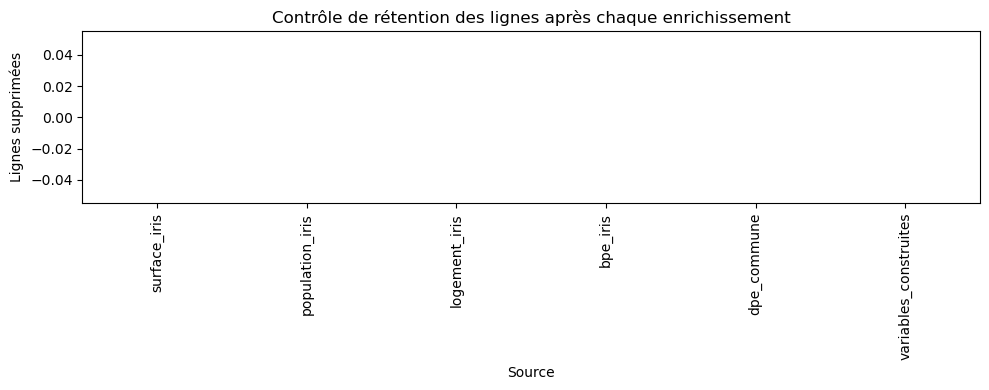

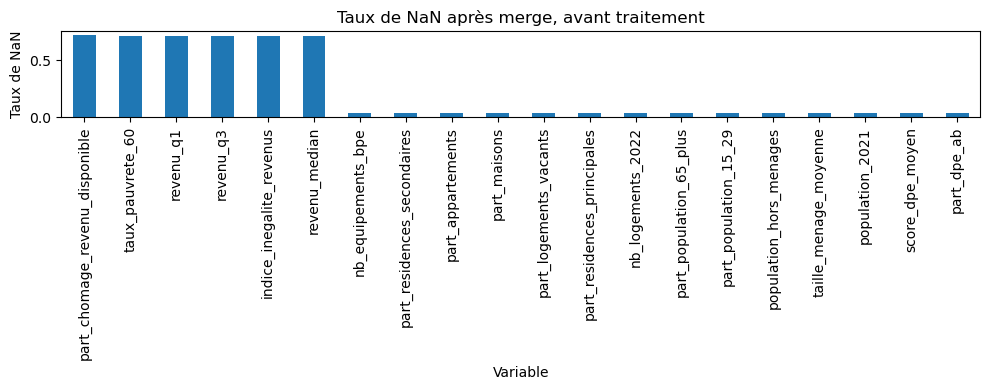

['c:\\Users\\club_\\OneDrive\\13_DOCUMENT\\SYSTEME_AIDE_DECISION_IMMOBILIERE\\outputs\\figures\\v15_retention_lignes_par_enrichissement.png',
 'c:\\Users\\club_\\OneDrive\\13_DOCUMENT\\SYSTEME_AIDE_DECISION_IMMOBILIERE\\outputs\\figures\\v15_nan_apres_merge_avant_traitement.png']

In [24]:
# Production des visualisations de suivi de la rétention des lignes et des taux de manquants après merge.
fig_paths = []

if not drop_report.empty:
    ax = drop_report.set_index("source")["rows_dropped"].plot(kind="bar", figsize=(10, 4), title="Contrôle de rétention des lignes après chaque enrichissement")
    ax.set_xlabel("Source")
    ax.set_ylabel("Lignes supprimées")
    plt.tight_layout()
    fig_path = PATHS["figures"] / "v15_retention_lignes_par_enrichissement.png"
    plt.savefig(fig_path, dpi=150)
    fig_paths.append(str(fig_path))
    plt.show()

if candidate_features:
    top_missing_before = na_report.sort_values("missing_rate_after_merge", ascending=False).head(20) if not na_report.empty else pd.DataFrame()
    if not top_missing_before.empty:
        ax = top_missing_before.set_index("variable")["missing_rate_after_merge"].plot(kind="bar", figsize=(10, 4), title="Taux de NaN après merge, avant traitement")
        ax.set_xlabel("Variable")
        ax.set_ylabel("Taux de NaN")
        plt.tight_layout()
        fig_path = PATHS["figures"] / "v15_nan_apres_merge_avant_traitement.png"
        plt.savefig(fig_path, dpi=150)
        fig_paths.append(str(fig_path))
        plt.show()

fig_paths


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Les enrichissements territoriaux présentent un très bon niveau de couverture globale. La majorité des variables affichent des taux de valeurs manquantes faibles, confirmant la robustesse des jointures réalisées sur le référentiel IRIS. Les variables socio-économiques issues de FiLoSoFi présentent des taux de NaN plus élevés, cohérents avec les limites de disponibilité statistique sur certains territoires ou maillages géographiques. Le contrôle de rétention montre qu’aucun enrichissement n’a entraîné de suppression de lignes. Les jointures ont donc été réalisées de manière non destructive, garantissant la conservation intégrale des mutations résidentielles du pipeline. Globalement, ces résultats confirment la stabilité du processus d’enrichissement territorial et la bonne qualité des données intégrées pour les futures analyses et phases de modélisation.</div>
</div>

In [25]:
# Construction du dictionnaire des variables territoriales retenues et de leur rôle métier.
feature_dictionary = pd.DataFrame([
    {"famille": fam, "variable": var}
    for fam, vars_ in territorial_feature_families.items()
    for var in vars_
    if var in base_micro_enrichie.columns
])

feature_dictionary["role"] = np.select(
    [
        feature_dictionary["variable"].eq("dpe_available"),
        feature_dictionary["famille"].eq("filosofi"),
    ],
    [
        "indicateur de disponibilite du signal DPE (0=absent, 1=present)",
        "contexte socio-economique impute par mediane si manquant",
    ],
    default="enrichissement territorial conserve, NaN residuels documentes",
)

display(feature_dictionary)


,famille,variable,role
0,filosofi,revenu_median,contexte socio-economique impute par mediane s...
1,filosofi,revenu_q1,contexte socio-economique impute par mediane s...
2,filosofi,revenu_q3,contexte socio-economique impute par mediane s...
3,filosofi,indice_inegalite_revenus,contexte socio-economique impute par mediane s...
4,filosofi,taux_pauvrete_60,contexte socio-economique impute par mediane s...
5,filosofi,part_chomage_revenu_disponible,contexte socio-economique impute par mediane s...
6,surface,surface_iris_km2,"enrichissement territorial conserve, NaN resid..."
7,population,population_2021,"enrichissement territorial conserve, NaN resid..."
8,population,taille_menage_moyenne,"enrichissement territorial conserve, NaN resid..."
9,population,population_hors_menages,"enrichissement territorial conserve, NaN resid..."


In [26]:
# Exports finaux (bases, rapports, manifest) pour la continuité des notebooks aval.
base_iris_enrichie = socle_iris.copy()

light_cols = [
    c for c in [
        "id_mutation", "date_mutation", "valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales",
        "code_iris", "code_commune", "code_departement"
    ] if c in base_micro_enrichie.columns
] + candidate_features + [
    c for c in base_micro_enrichie.columns
    if c.endswith("_manquant_avant_imputation") or c.endswith("_flag") or c.endswith("_available")
]

# Suppression des doublons d'ordre en conservant l'ordre.
seen = set()
light_cols = [c for c in light_cols if not (c in seen or seen.add(c))]
base_micro_light = base_micro_enrichie[light_cols].copy()

base_iris_enrichie.to_parquet(OUTPUTS["iris_enrichi"], index=False)
base_micro_enrichie.to_parquet(OUTPUTS["micro_enrichi"], index=False)
base_micro_light.to_parquet(OUTPUTS["micro_light"], index=False)
merge_report.to_csv(OUTPUTS["merge_report"], index=False)
drop_report.to_csv(OUTPUTS["drop_report"], index=False)
imputation_report.to_csv(OUTPUTS["imputation_report"], index=False)
schema_report.to_csv(OUTPUTS["schema_report"], index=False)
feature_dictionary.to_csv(OUTPUTS["feature_dictionary"], index=False)

manifest = {
    "notebook": "05_enrichissement_territorial",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "input": str(CONFIG["input_00_04"]),
    "outputs": {k: str(v) for k, v in OUTPUTS.items()},
    "figures": fig_paths,
    "rows_input_micro": int(rows_micro_before),
    "rows_output_micro": int(len(base_micro_enrichie)),
    "rows_output_iris": int(len(base_iris_enrichie)),
    "nan_policy": {
        "filosofi": "imputation mediane commune -> departement -> globale + flags",
        "autres_enrichissements": "conservation des IRIS, NaN résiduels tracés dans les rapports",
        "dpe": "dpe_available et dpe_missing_flag ; nb_dpe=0 si absence de signal ; scores DPE laissés à NaN",
        "rattachement_micro_final": "conservation des transactions et signalement des lignes non rapprochées par flags",
    },
    "candidate_features": candidate_features,
}

with open(OUTPUTS["manifest"], "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("Exports réalisés :")
for label, path in OUTPUTS.items():
    print(f"- {label}: {path}")


Exports réalisés :
- iris_enrichi: c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_iris_territoire_enrichi.parquet
- micro_enrichi: c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_territoire.parquet
- micro_light: c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_territoire_light.parquet
- merge_report: c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\rapport_merges_territorial.csv
- drop_report: c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\rapport_retention_lignes_territorial.csv
- imputation_report: c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\rapport_imputation_territorial.csv
- schema_report: c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\schema_variables_territoriales.csv
- feature_dictionary: c:\Users\c

In [27]:
# Diagnostic final des valeurs manquantes.
# L'objectif n'est pas d'avoir zéro NaN partout,
# mais de vérifier que les valeurs manquantes restantes
# sont connues, expliquées et maîtrisées.

missing_summary = pd.DataFrame({
    "variable": socle_iris.columns,
    "missing_rate_final": socle_iris.isna().mean().values,
    "n_missing": socle_iris.isna().sum().values,
    "n_unique": socle_iris.nunique(dropna=True).values,
    "dtype": socle_iris.dtypes.astype(str).values,
})

missing_summary = (
    missing_summary
    .sort_values(
        by="missing_rate_final",
        ascending=False
    )
    .reset_index(drop=True)
)

# Affichage uniquement des variables présentant encore des NaN.
missing_remaining = missing_summary[
    missing_summary["missing_rate_final"] > 0
]

display(missing_remaining)

print(
    "Nombre de variables avec valeurs manquantes :",
    len(missing_remaining)
)

print(
    "Taux maximal de valeurs manquantes :",
    round(
        missing_remaining["missing_rate_final"].max() * 100,
        2
    ),
    "%"
)

,variable,missing_rate_final,n_missing,n_unique,dtype
0,nb_equipements_bpe,0.038711,1850,550,float64
1,part_appartements,0.038690,1849,39432,Float64
2,part_maisons,0.038690,1849,40378,Float64
3,part_logements_vacants,0.038690,1849,42777,Float64
4,part_residences_secondaires,0.038690,1849,42666,Float64
5,part_residences_principales,0.038690,1849,44028,Float64
6,densite_logements_km2,0.038502,1840,45942,Float64
7,nb_logements_2022,0.038502,1840,40636,Float64
8,part_population_65_plus,0.038313,1831,44255,Float64
9,part_population_15_29,0.038313,1831,43614,Float64


Nombre de variables avec valeurs manquantes : 20
Taux maximal de valeurs manquantes : 3.87 %


In [28]:
# Bilan final des valeurs manquantes sur le socle IRIS enrichi.
# L'objectif n'est pas d'obtenir une complétude parfaite,
# mais d'identifier les variables qui restent partiellement renseignées
# avant les étapes aval du pipeline.

missing_summary_iris = pd.DataFrame({
    "variable": socle_iris.columns,
    "missing_rate_final": socle_iris.isna().mean().values,
    "n_missing": socle_iris.isna().sum().values,
    "n_unique": socle_iris.nunique(dropna=True).values,
    "dtype": socle_iris.dtypes.astype(str).values,
})

missing_summary_iris = (
    missing_summary_iris
    .sort_values("missing_rate_final", ascending=False)
    .reset_index(drop=True)
)

missing_remaining_iris = missing_summary_iris[
    missing_summary_iris["missing_rate_final"] > 0
]

display(missing_remaining_iris.head(30))

print("Variables avec valeurs manquantes :", len(missing_remaining_iris))

if not missing_remaining_iris.empty:
    print(
        "Taux maximal de valeurs manquantes :",
        round(missing_remaining_iris["missing_rate_final"].max() * 100, 2),
        "%"
    )
else:
    print("Aucune valeur manquante résiduelle détectée.")

,variable,missing_rate_final,n_missing,n_unique,dtype
0,nb_equipements_bpe,0.038711,1850,550,float64
1,part_appartements,0.038690,1849,39432,Float64
2,part_maisons,0.038690,1849,40378,Float64
3,part_logements_vacants,0.038690,1849,42777,Float64
4,part_residences_secondaires,0.038690,1849,42666,Float64
5,part_residences_principales,0.038690,1849,44028,Float64
6,densite_logements_km2,0.038502,1840,45942,Float64
7,nb_logements_2022,0.038502,1840,40636,Float64
8,part_population_65_plus,0.038313,1831,44255,Float64
9,part_population_15_29,0.038313,1831,43614,Float64


Variables avec valeurs manquantes : 20
Taux maximal de valeurs manquantes : 3.87 %


In [ ]:
# Analyse de complétude finale des enrichissements territoriaux.
# Les valeurs manquantes ne déclenchent pas de suppression automatique :
# elles sont documentées afin d'évaluer :
# - la couverture des différentes sources ;
# - la stabilité des jointures territoriales ;
# - et les futurs besoins d'imputation ou d'exclusion en modélisation.

seuil_attention = 0.05

variables_a_surveiller = missing_summary_iris[
    missing_summary_iris["missing_rate_final"] >= seuil_attention
]

print(
    f"Variables avec plus de {seuil_attention:.0%} "
    f"de valeurs manquantes : {len(variables_a_surveiller)}"
)

display(
    variables_a_surveiller[
        ["variable", "missing_rate_final", "n_missing", "dtype"]
    ].sort_values("missing_rate_final", ascending=False)
)

Variables avec plus de 20% de valeurs manquantes : 0


,variable,missing_rate_final,n_missing,dtype


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Les taux de valeurs manquantes observés proviennent principalement de zones IRIS non couvertes par certaines sources externes ou de limites de disponibilité statistique territoriale.</h3>
  <div style="color: #4b5563; font-size: 14px;">Les valeurs manquantes sont donc fortement corrélées entre elles et doivent être interprétées comme des absences de couverture géographique plutôt que comme des anomalies indépendantes variable par variable.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Synthèse du notebook 05</h3>
  <div style="color: #4b5563; font-size: 14px;">Ce notebook transforme le rattachement IRIS en enrichissement territorial exploitable pour l’analyse immobilière. Il ajoute au socle DVF : des variables socio-économiques ; des indicateurs démographiques ; des données sur le parc de logements ; des équipements de proximité (BPE) ; des indicateurs énergétiques DPE ; des variables de surface et de densité territoriale. L’approche reste non destructive : les lignes sont conservées, les valeurs manquantes sont documentées et les arbitrages d’exclusion sont reportés aux étapes aval. Le notebook produit ainsi une base immobilière enrichie de son contexte territorial, destinée aux futures analyses spatiales et aux modèles prédictifs.</div>
</div>